# **Project Name / Proje İsmi** : Car Price Prediction / Araba Fiyat Tahmini

## 1. Understanding the Data / Veriyi Anlamak

### Importing Necessary Libraries / Gerekli Kütüphanelerin Import Edilmesi

In [1]:
# For Data Preprocessing and & Data Wrangling / Veri Önişleme ve Veri Temizleme

import numpy as np
import pandas as pd

# Tools for Visualization / Görselleştirme için Araçlar

import seaborn as sns
import matplotlib.pyplot as plt 
# %matplotlib.inline / Bu kısım da eklenebilir.

# Preprocessing Libraries / Önişleme Kütüphaneleri

from sklearn.preprocessing import MinMaxScaler,StandardScaler
# Model Selection Libraries / Model Seçim Kütüphaneleri
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV

# ML Models / Makine Öğrenmesi Modelleri

from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
import xgboost as xgb

# Evaluation Metrics / Değerlendirme Metrikleri
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

# Decision Tree Visualization / Karar Ağacının Görselleştirilmesi
from sklearn.tree import export_graphviz
from sklearn import tree
from IPython.display import SVG,display
from graphviz import Source

# For ignoring Warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('car_data.csv')

In [3]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.shape

(301, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
df.duplicated().sum()

2

In [7]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

## 2. Exploring the Variables in the Dataset / Veri Setindeki Değişkenleri Keşfetmek

In [8]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [9]:
df.describe(include= 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.642584,0.32,1.2,6.4,9.9,92.6
Driven_kms,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Selling_type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


In [10]:
## Unique Values per Variable

for u in df.columns.tolist():
    print('Number of Unique Values in',u,'is : ',df[u].nunique())

Number of Unique Values in Car_Name is :  98
Number of Unique Values in Year is :  16
Number of Unique Values in Selling_Price is :  156
Number of Unique Values in Present_Price is :  148
Number of Unique Values in Driven_kms is :  206
Number of Unique Values in Fuel_Type is :  3
Number of Unique Values in Selling_type is :  2
Number of Unique Values in Transmission is :  2
Number of Unique Values in Owner is :  3


## 3. Data Wrangling (Data Cleaning and Preparation) / Veri Temizleme ve Hazırlama

In [11]:
df['Current_Year'] = 2025

# Calculation for Age of the Car
df['Age_of_Car'] = df['Current_Year'] - df['Year']

df.drop(['Current_Year'],axis = 1,inplace = True)

In [12]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Age_of_Car
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


In [13]:
# Defining Dependent Variable / So it will be 'y'

dependent_var = ['Selling_Price']

## 4. Exploring Relationships Between Variables Using Data Visualization / Veri Görselleştirmesi ile Değişkenler Arasındaki İlişkileri Keşfetmek

### Plot 1 : Top 10 Most Selling Car

In [14]:
df['Car_Name'].value_counts().head(10)

Car_Name
city             26
corolla altis    16
verna            14
fortuner         11
brio             10
ciaz              9
innova            9
i20               9
grand i10         8
jazz              7
Name: count, dtype: int64

In [15]:
top_10 = df['Car_Name'].value_counts()[:10]

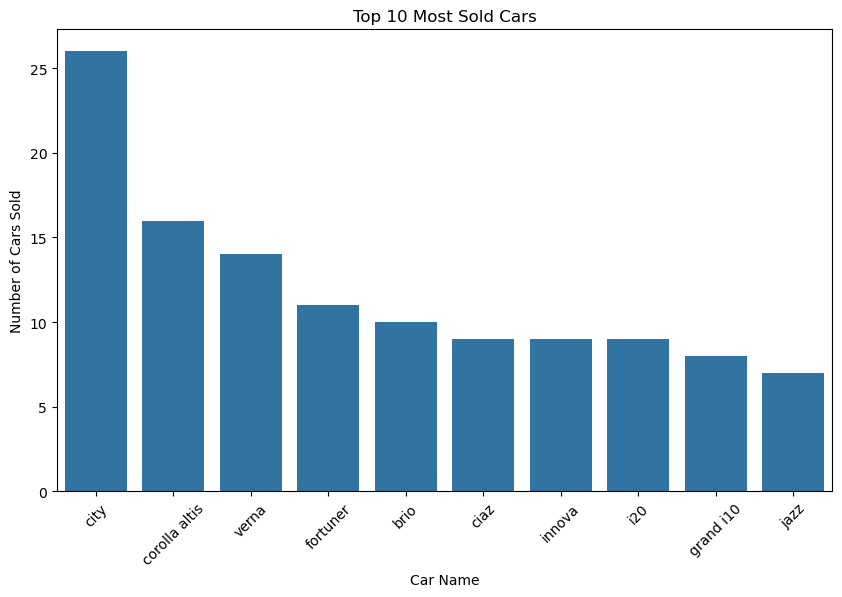

In [16]:
plt.figure(figsize = (10,6))
sns.countplot(x = 'Car_Name', data = df, order = top_10.index)

plt.xlabel('Car Name')
plt.ylabel('Number of Cars Sold')
plt.title('Top 10 Most Sold Cars') 
plt.xticks(rotation=45)  # İsimler uzun ise daha okunaklı olması için

plt.show()

### Plot 2 : Number of Cars Bought Each Year / Her Yıl Alınan Araba Sayısı

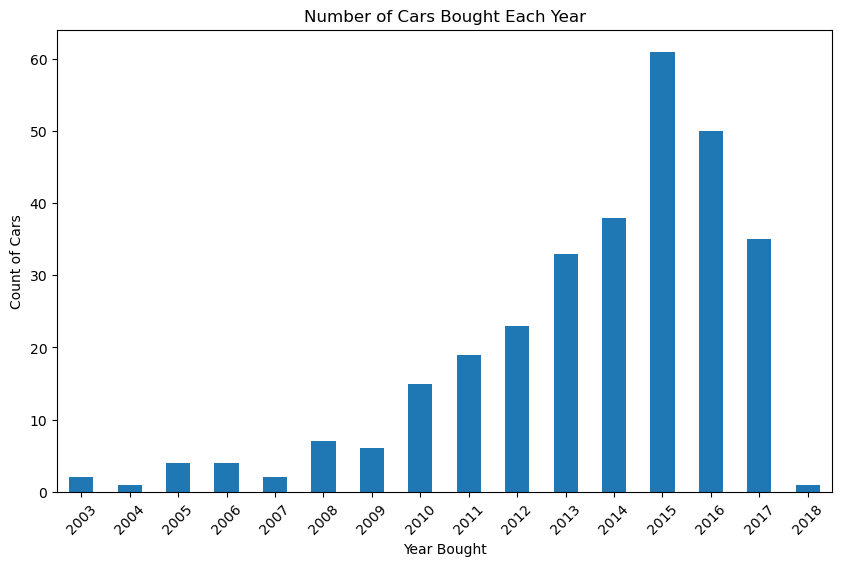

In [17]:
plt.figure(figsize=(10, 6))

# Grouping the data by the 'Year' / Yıl Kategorisine Göre Gruplama İşlemi
yearly_counts = df.groupby('Year').count()['Car_Name']

# Creating a bar plot to visualize / Görselleştirme için Bar Plot Oluşturma
yearly_counts.plot(kind='bar')

# Setting Labels and Title for Plots / Grafikler için Etiketler ve Başlık Ayarlama
plt.xlabel('Year Bought')
plt.ylabel('Count of Cars')
plt.title('Number of Cars Bought Each Year')
plt.xticks(rotation=45)

plt.show()

### Plot 3: Categorical Variable Distribution / Kategorik Değişken Dağılımı

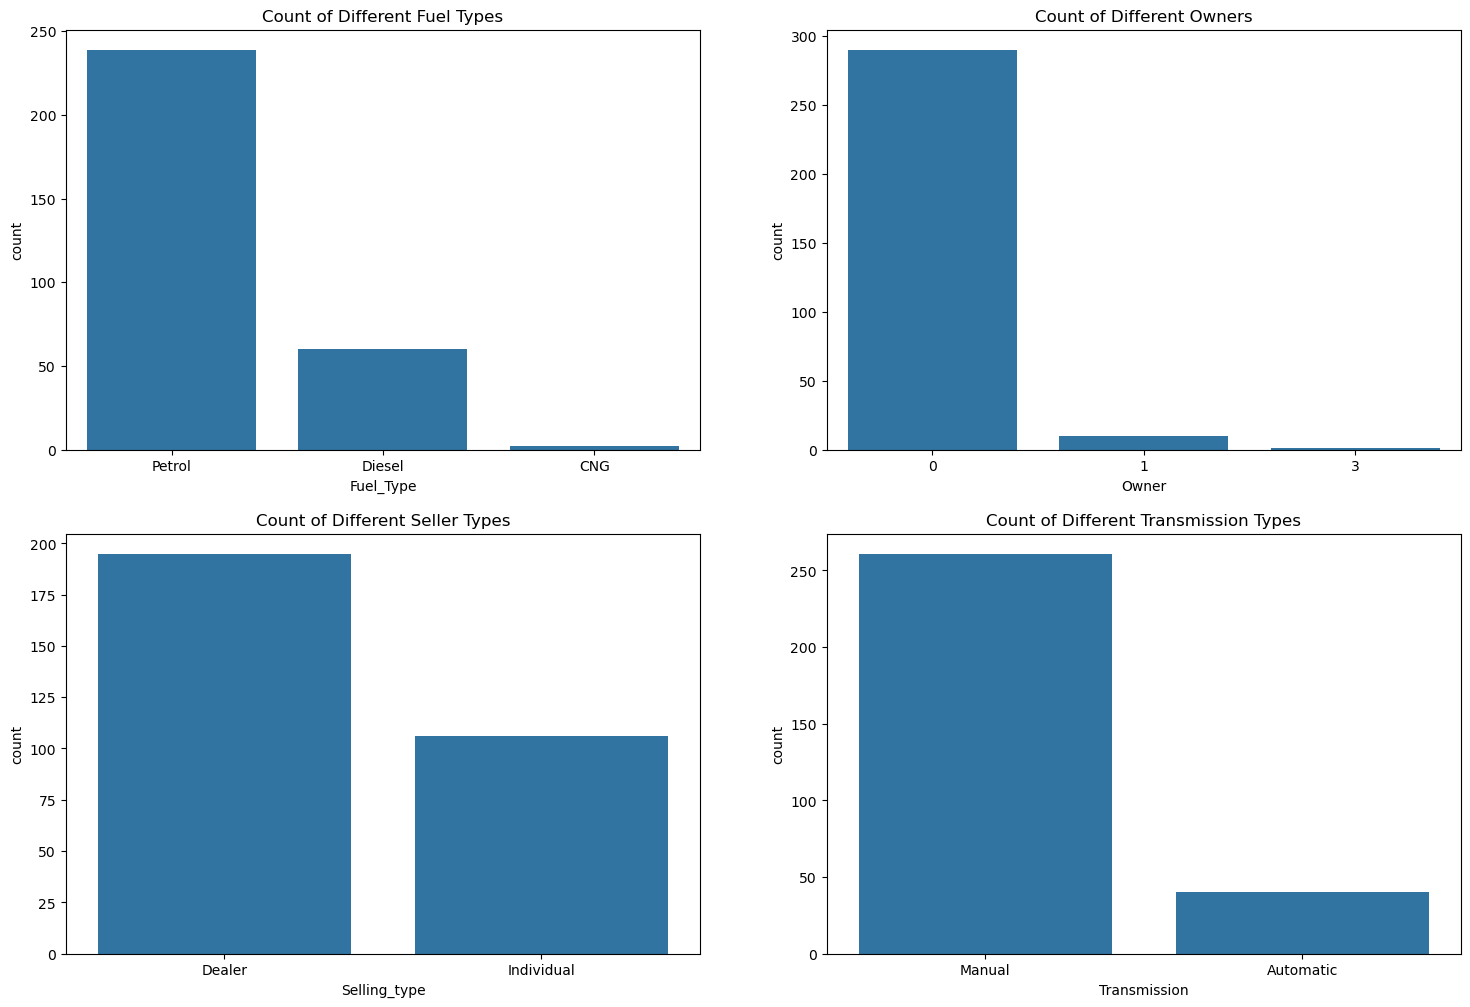

In [18]:
# Setting Figure Size for 2x2 Subplots / 2x2 Alt Grafikler için Figure Boyutunu Ayarlama
plt.figure(figsize= (18,12))

# Subplot 1: Distribution of Fuel Types / Yakıt Türlerinin Dağılımı
plt.subplot(2,2,1)
sns.countplot(data=df, x = 'Fuel_Type')
plt.title("Count of Different Fuel Types")

# Subplot 2: Distribution of Owners / Araç Sahiplerinin Dağılımı
plt.subplot(2,2,2)
sns.countplot(data=df, x = 'Owner')
plt.title("Count of Different Owners")

# Subplot 3: Distribution of Seller Types / Satıcı Türlerinin Dağılımı
plt.subplot(2,2,3)
sns.countplot(data=df, x = 'Selling_type')
plt.title("Count of Different Seller Types")

# Subplot 4: Distribution of Transmission Types / Vites Tiplerinin Dağılımı
plt.subplot(2,2,4)
sns.countplot(data=df, x = 'Transmission')
plt.title("Count of Different Transmission Types")

plt.show()

### Plot 4: Relationship Between Categorical Variables and Target Variable / Kategorik Değişkenler ile Hedef Değişken Arasındaki İlişki


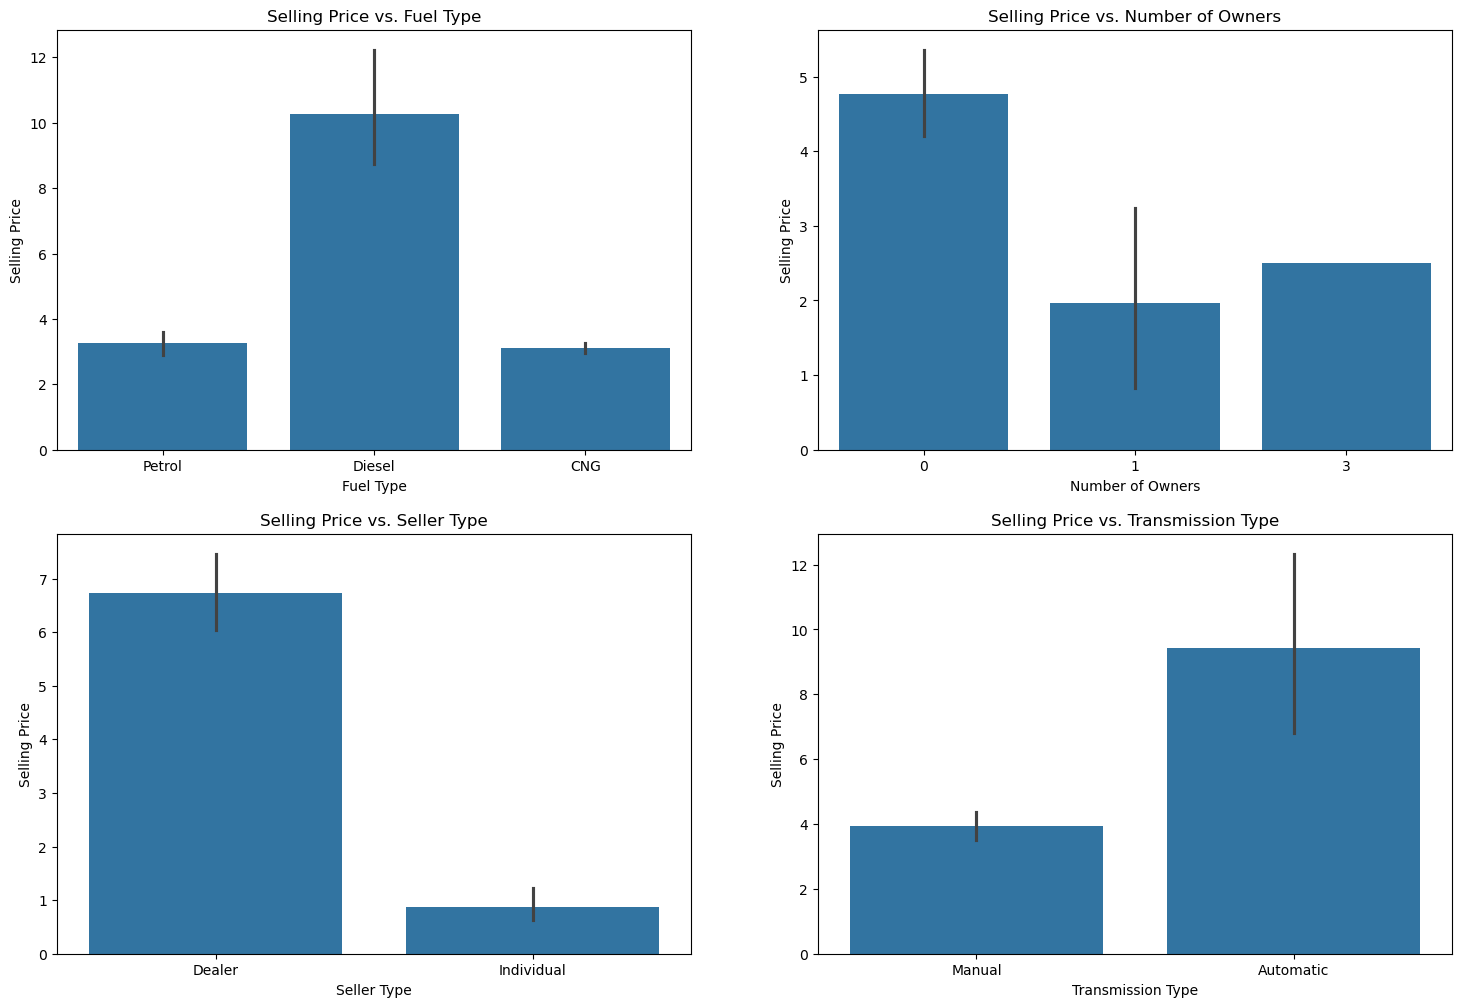

In [19]:
plt.figure(figsize=(18,12))

# Subplot 1: Average Selling Price by Fuel Type / Yakıt Türüne Göre Ortalama Satış Fiyatı
plt.subplot(2,2,1)
sns.barplot(data=df, x='Fuel_Type', y='Selling_Price')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.title('Selling Price vs. Fuel Type')

# Subplot 2: Average Selling Price by Number of Owners / Sahip Sayısına Göre Ortalama Satış Fiyatı
plt.subplot(2,2,2)
sns.barplot(data=df, x='Owner', y='Selling_Price')
plt.xlabel('Number of Owners')
plt.ylabel('Selling Price')
plt.title('Selling Price vs. Number of Owners')

# Subplot 3: Average Selling Price by Seller Type / Satıcı Türüne Göre Ortalama Satış Fiyatı
plt.subplot(2,2,3)
sns.barplot(data=df, x='Selling_type', y='Selling_Price')
plt.xlabel('Seller Type')
plt.ylabel('Selling Price')
plt.title('Selling Price vs. Seller Type')

# Subplot 4: Average Selling Price by Transmission / Vites Tipine Göre Ortalama Satış Fiyatı
plt.subplot(2,2,4)
sns.barplot(data=df, x='Transmission', y='Selling_Price')
plt.xlabel('Transmission Type')
plt.ylabel('Selling Price')
plt.title('Selling Price vs. Transmission Type')

plt.show()

### Plot 5: Price vs Mileage / Fiyat ve Kilometre

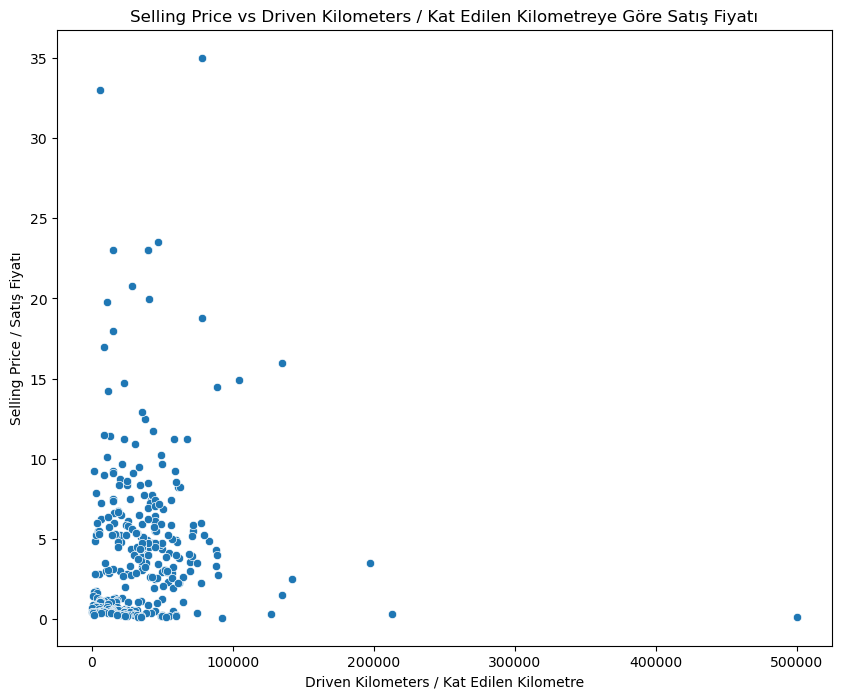

In [20]:
plt.figure(figsize=(10,8))

# Scatter plot to explore how Selling Price changes with Driven Kilometers
# Satış Fiyatının Kat Edilen Kilometreye Göre Nasıl Değiştiğini İncelemek için Dağılım Grafiği
sns.scatterplot(data=df, x='Driven_kms', y='Selling_Price')

# Set labels for the x and y axes / X ve Y eksenlerini ayarlama
plt.xlabel('Driven Kilometers / Kat Edilen Kilometre')
plt.ylabel('Selling Price / Satış Fiyatı')

# Set title for the plot / Grafiğin başlığını ayarlama
plt.title('Selling Price vs Driven Kilometers / Kat Edilen Kilometreye Göre Satış Fiyatı')

plt.show()

### Plot 6: Feature Correlations / Özellikler Arası Korelasyon

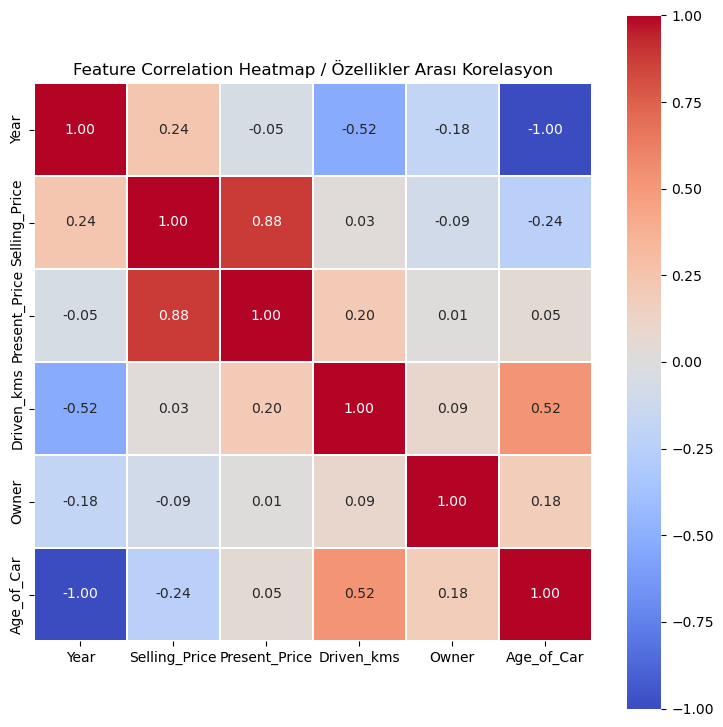

In [21]:
numeric_df = df.select_dtypes(include='number')  # sadece sayısal sütunları al

# Setting the figure size / Grafik boyutunu ayarlamak
plt.figure(figsize=(9, 9))

# Creating a correlation heatmap with annotated values / Değerleri gösterilen korelasyon ısı haritasını oluşturmak
sns.heatmap(numeric_df.corr(), annot=True, linewidths=0.1, fmt='.2f', square=True, cmap='coolwarm')

# Adding a title to the plot / Grafiğe başlık eklemek
plt.title("Feature Correlation Heatmap / Özellikler Arası Korelasyon")

# Displaying the plot / Grafiği göstermek
plt.show()

## 5. Feature Engineering and Data Preprocessing / Öznitelik Mühendisliği ve Veri Ön İşleme

### 1. Detecting and Handling Outliers / Aykırı Değerleri Tespit Etme ve İşleme

In [22]:
# Removing outliers using the IQR method / IQR yöntemi ile aykırı değerleri kaldırmak
q_1, median, q_3 = df['Selling_Price'].quantile([0.25,0.5,0.75])

lower_limit = q_1 - 1.5 * (q_3 - q_1)
upper_limit = q_3 + 1.5 * (q_3 - q_1)

df['Selling_Price'] = df['Selling_Price'].apply(
    lambda x: median if (x > upper_limit or x < lower_limit) else x
)

# Detecting and Removing Outliers by Capping / Uç Değerleri Tespit Edip Sınırlandırmak
for col in ['Present_Price','Driven_kms','Owner','Age_of_Car']:
  upper_limit = df[col].quantile(0.99)
  df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

### 2. Encoding Categorical Variables / Kategorik Değişkenleri Kodlama İşlemi

In [23]:
df.drop(['Car_Name'], axis=1, inplace=True)
df = pd.get_dummies(df)

### 3. Manipulating and Selecting Features / Özellikleri Dönüştürme ve Seçme İşlemleri


#### 1. Manipulating Features

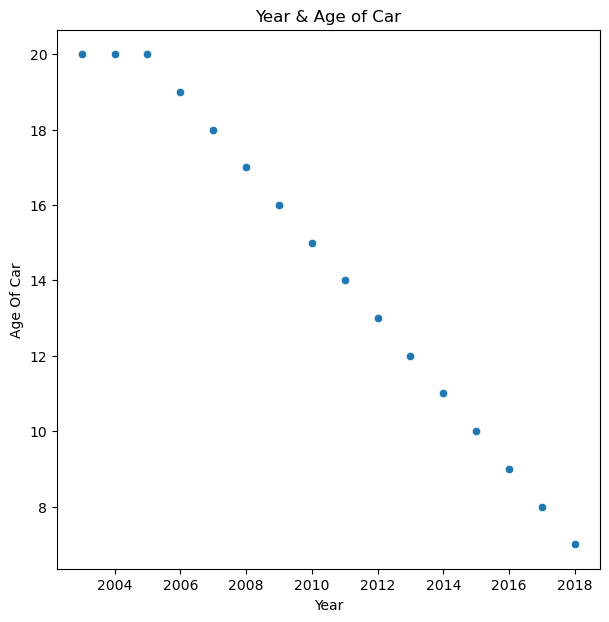

In [24]:
plt.figure(figsize=(7,7))
sns.scatterplot(x='Year',y='Age_of_Car',data=df)
plt.xlabel('Year')
plt.ylabel('Age Of Car')
plt.title('Year & Age of Car')
plt.show()

In [25]:
df[['Year','Age_of_Car']].corr()

,Year,Age_of_Car
Year,1.000000,-0.998376
Age_of_Car,-0.998376,1.000000


In [26]:
# Dropping the 'Year' column since the car's age has already been calculated in 'no_year'
# 'Year' sütunu kaldırılıyor çünkü aracın yaşı zaten 'no_year' sütununda hesaplandı
df.drop('Year', axis=1, inplace=True)

#### 2. Selecting Features

In [27]:
Features = [i for i in df.columns if i not in ['Selling_Price']]
Features

['Present_Price',
 'Driven_kms',
 'Owner',
 'Age_of_Car',
 'Fuel_Type_CNG',
 'Fuel_Type_Diesel',
 'Fuel_Type_Petrol',
 'Selling_type_Dealer',
 'Selling_type_Individual',
 'Transmission_Automatic',
 'Transmission_Manual']

In [28]:
# Reducing multicollinearity using the Variance Inflation Factor (VIF) method
# Çoklu doğrusal bağlantıyı (multicollinearity) VIF yöntemi ile azaltma

from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    """
    Calculates the Variance Inflation Factor for each feature in the dataset
    Her bir özellik için Varyans Şişme Faktörünü (VIF) hesaplar
    """
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    
    return vif_data

In [29]:
continuous_variables = ['Present_Price', 'Driven_kms', 'Owner', 'Age_of_Car']

continuous_features_df = pd.DataFrame(df[continuous_variables])

In [30]:
continuous_features_df

,Present_Price,Driven_kms,Owner,Age_of_Car
0,5.59,27000.0,0.0,11.0
1,9.54,43000.0,0.0,12.0
2,9.85,6900.0,0.0,8.0
3,4.15,5200.0,0.0,14.0
4,6.87,42450.0,0.0,11.0
...,...,...,...,...
296,11.60,33988.0,0.0,9.0
297,5.90,60000.0,0.0,10.0
298,11.00,87934.0,0.0,16.0
299,12.50,9000.0,0.0,8.0


In [31]:
calculate_vif(df[[i for i in continuous_features_df]])
     

,Feature,VIF
0,Present_Price,2.187052
1,Driven_kms,4.509676
2,Owner,1.059124
3,Age_of_Car,4.328862


In [32]:
# Previewing the final dataset ready for modeling
# Modelleme için hazır hâle getirilmiş son veri setini önizleme
df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Age_of_Car,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Dealer,Selling_type_Individual,Transmission_Automatic,Transmission_Manual
0,3.35,5.59,27000.0,0.0,11.0,False,False,True,True,False,False,True
1,4.75,9.54,43000.0,0.0,12.0,False,True,False,True,False,False,True
2,7.25,9.85,6900.0,0.0,8.0,False,False,True,True,False,False,True
3,2.85,4.15,5200.0,0.0,14.0,False,False,True,True,False,False,True
4,4.60,6.87,42450.0,0.0,11.0,False,True,False,True,False,False,True


### 4. Transforming Data / Veriyi Dönüştürme İşlemleri

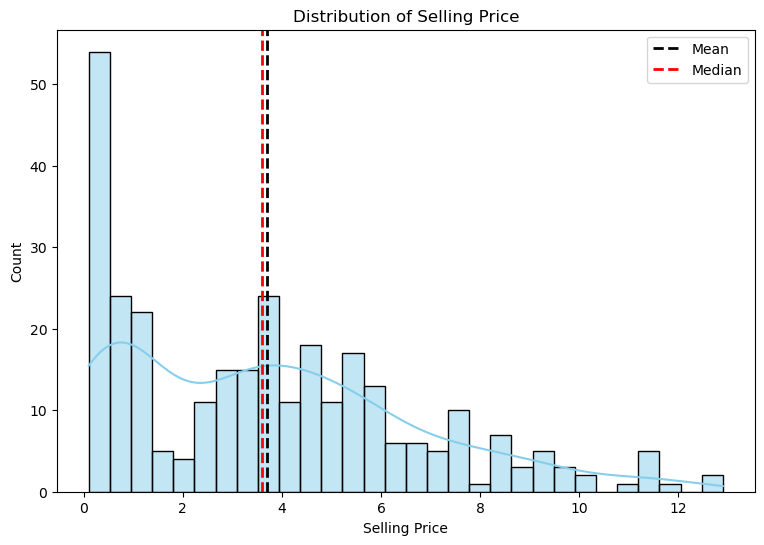

In [33]:
plt.figure(figsize=(9,6))

# Plotting the distribution of the target variable
# Hedef değişkenin dağılımını görselleştirme
sns.histplot(df[dependent_var[0]], kde=True, bins=30, color='skyblue')

# Setting axis labels
plt.xlabel('Selling Price')
plt.ylabel('Count')

# Adding title
plt.title('Distribution of Selling Price')

# Marking mean and median
plt.axvline(df[dependent_var[0]].mean(), color='black', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(df[dependent_var[0]].median(), color='red', linestyle='dashed', linewidth=2, label='Median')

# Adding legend
plt.legend()

plt.show()

In [34]:
# Checking the skewness of the target variable
# Bağımlı değişkenin çarpıklığını kontrol etme
df[dependent_var].skew()

Selling_Price    0.757016
dtype: float64

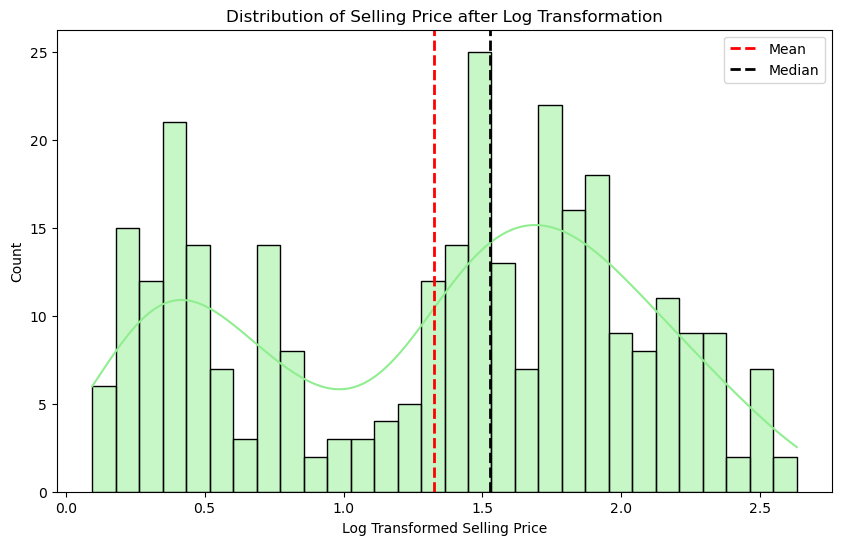

In [35]:
plt.figure(figsize=(10,6))

# Visualizing the distribution of target variable after log transformation
# Log dönüşümü sonrası bağımlı değişkenin dağılımını görselleştirme
sns.histplot(np.log1p(df[dependent_var[0]]), kde=True, bins=30, color='lightgreen')

# Setting axis labels
plt.xlabel('Log Transformed Selling Price')
plt.ylabel('Count')

# Adding title
plt.title('Distribution of Selling Price after Log Transformation')

# Marking mean and median
plt.axvline(np.log1p(df[dependent_var[0]]).mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(np.log1p(df[dependent_var[0]]).median(), color='black', linestyle='dashed', linewidth=2, label='Median')

# Adding legend
plt.legend()

plt.show()


In [36]:
# Checking skewness of the target variable after log transformation
# Log dönüşümü sonrası bağımlı değişkenin çarpıklığını kontrol etme
np.log1p(df[dependent_var[0]]).skew()


-0.2223561302783033

In [37]:
# Defining independent (features) and dependent (target) variables
# Bağımsız (özellikler) ve bağımlı (hedef) değişkenleri tanımlama
X = df.drop('Selling_Price', axis=1)
y = np.log1p(df[dependent_var[0]])

In [38]:
Features

['Present_Price',
 'Driven_kms',
 'Owner',
 'Age_of_Car',
 'Fuel_Type_CNG',
 'Fuel_Type_Diesel',
 'Fuel_Type_Petrol',
 'Selling_type_Dealer',
 'Selling_type_Individual',
 'Transmission_Automatic',
 'Transmission_Manual']

### 5. Feature Scaling / Özellikleri Ölçeklendirme

In [39]:
Features = [i for i in df.columns if i not in ['Selling_Price']]

# Initializing the scaler
# Ölçeklendirici (StandardScaler) nesnesini oluşturma
scaler = StandardScaler()

# Scaling the features
# Özellikleri ölçeklendirme (ortalama=0, standart sapma=1)
X = scaler.fit_transform(df[Features])

I applied the **StandardScaler** to scale the features because the independent variables have different units and ranges. Scaling them brings all features to a similar scale, which helps many machine learning algorithms perform better.
***
Bağımsız değişkenler farklı birim ve ölçeklere sahip olduğu için **StandardScaler** yöntemi ile özellikleri ölçeklendirdim. Bu sayede tüm özellikler benzer bir ölçeğe getirilmiş oldu ve birçok makine öğrenmesi algoritmasının performansı artar.

### 6. Splitting Data for Modeling / Modelleme İçin Veriyi Eğitim ve Test Setlerine Bölme

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [41]:
y_train.value_counts()

Selling_Price
1.526056    13
0.470004     7
0.371564     7
1.704748     5
1.609438     5
            ..
0.139762     1
1.960095     1
0.095310     1
1.722767     1
1.791759     1
Name: count, Length: 127, dtype: int64

## 6. Machine Learning Models and Explanations / Makine Öğrenimi Modelleri ve Açıklamaları

In [42]:
# Function to evaluate a regression model / Regresyon modelini değerlendiren fonksiyon
def evaluate_model(model, y_test, y_pred):

  # Apply inverse log transformation to y_test and y_pred to revert the log transformation applied earlier
  # Log dönüşümünü tersine çevirmek için y_test ve y_pred üzerinde ters log dönüşümü uygula
  y_texp = np.exp(y_test)  # Gerçek test değerlerini log dönüşümünden çıkar / Apply inverse log transformation on the actual test data
  y_pexp = np.exp(y_pred)  # Model tahminlerini log dönüşümünden çıkar / Apply inverse log transformation on the predicted values
  y_train2 = np.exp(y_train)  # Eğitim verisini ters log dönüşümü ile geri al / Apply inverse log transformation on the training data
  y_train_pred = np.exp(model.predict(X_train))  # Modelin eğitim verisi üzerindeki tahminini ters log dönüşümü ile geri al / Apply inverse log transformation on the predictions for the training data

  # Calculating Evaluation Metrics / Değerlendirme Metriklerini Hesaplama
  mse = mean_squared_error(y_texp, y_pexp) 
  rmse = np.sqrt(mse) 
  mae = mean_absolute_error(y_texp, y_pexp) 
  r2_train = r2_score(y_train2, y_train_pred) 
  r2 = r2_score(y_texp, y_pexp) 
  r2_adj = 1 - (1 - r2) * ((len(X_test) - 1) / (len(X_test) - X_test.shape[1] - 1)) # Adjusted R2

  # Displaying the evaluation metrics / Değerlendirme metriklerini yazdırma
  print("MSE :", mse) 
  print("RMSE :", rmse)  
  print("MAE :", mae)  
  print("Train R2 :", r2_train) 
  print("Test R2 :", r2)  
  print("Adjusted R2 : ", r2_adj)  

  # Visualizing the predicted and actual values for comparison / Tahmin edilen ve gerçek değerleri karşılaştırmalı olarak görselleştirme
  plt.figure(figsize=(12,7))  
  plt.plot((y_pexp)[:100]) 
  plt.plot((np.array(y_texp)[:100]))  
  plt.legend(["Predicted", "Actual"]) 
  plt.title('Actual and Predicted Selling Price', fontsize = 12)

  try:
    importance = model.feature_importances_  # Eğer model özellliklerin önem derecelerini sağlıyorsa, al / Get feature importances if the model provides them
  except:
    importance = model.coef_  # Eğer model coef_ kullanıyorsa, onları al / If the model uses coef_, retrieve them
  importance = np.absolute(importance)  # Özelliklerin önem derecelerinin mutlak değerlerini al / Get the absolute values of feature importances
  if len(importance) == len(Features):  # Eğer özelliklerin sayısı ile "importance" sayısı eşitse, işlem yapma / If the lengths match, do nothing
    pass
  else:
    importance = importance[0]  # Farklı bir durumda, yalnızca ilk öğeyi al / Otherwise, take the first element only

  # Plotting the top 5 most important features / En önemli 5 özelliği görselleştirme
  feat = pd.Series(importance, index = Features) 
  plt.figure(figsize = (8,4))  
  plt.title('Top 5 Most Important Features for ' + str(model), fontsize=12)  
  plt.xlabel('Relative Importance')  
  feat.nlargest(5).plot(kind='barh')  

  # Returning the model scores for further analysis / Modelin değerlendirme skorlarını geri döndürme
  model_score = [mse, rmse, mae, r2_train, r2, r2_adj] 
  return model_score  # Skorları geri döndür / Return the model scores

# Creating a DataFrame for the evaluation scores / Değerlendirme skorları için bir DataFrame oluşturma
Score = pd.DataFrame(index = ['MSE', 'RMSE', 'MAE', 'Train R2', 'Test R2', 'Adjusted R2'])  

### ML Models

### Linear Regression

In [43]:
lreg = LinearRegression()

lreg.fit(X_train,y_train)

y_pred_lr1 = lreg.predict(X_test)

#### 1. ML Model and Performance Evaluation / ML Modeli ve Performans Değerlendirmesi

MSE : 3.877120894565177
RMSE : 1.9690406025689713
MAE : 1.2676387960836515
Train R2 : 0.6257048995678873
Test R2 : 0.5714804001829716
Adjusted R2 :  0.4752821226730265


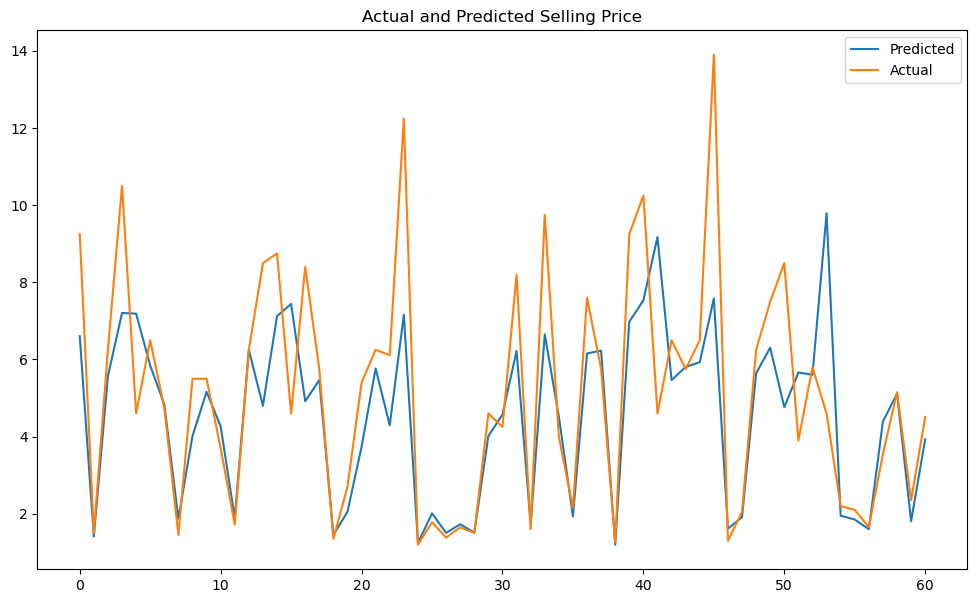

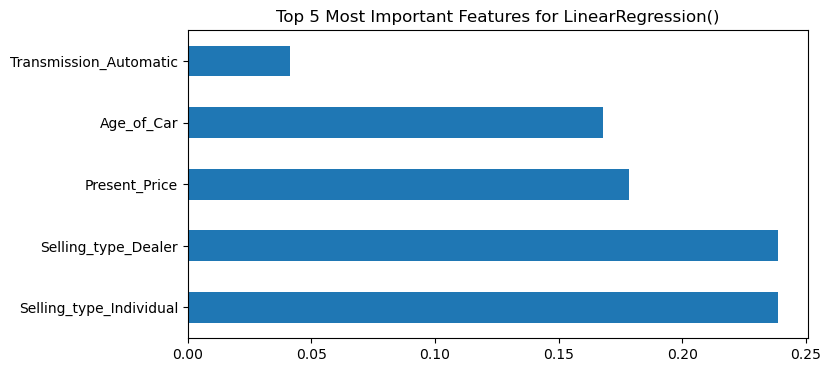

In [44]:
lreg_score = evaluate_model(lreg, y_test,y_pred_lr1)
Score['Linear regression'] = lreg_score

In [45]:
Score

,Linear regression
MSE,3.877121
RMSE,1.969041
MAE,1.267639
Train R2,0.625705
Test R2,0.571480
Adjusted R2,0.475282


#### 2. Cross Validation & Hyperparameter Tuning / Çapraz Doğrulama ve Hiperparametre Ayarlamaları

In [46]:
lreg = LinearRegression()

param_grid = {'fit_intercept' : [True,False]}

# Performing grid search
grid_search = GridSearchCV(lreg, param_grid, cv = 5, scoring = 'r2', return_train_score = True)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LinearRegression(),
             param_grid={'fit_intercept': [True, False]},
             return_train_score=True, scoring='r2')

In [47]:
print("Best R`2 score: ", grid_search.best_score_)

Best R`2 score:  0.7659703527889243


In [48]:
# Using the Best Parameters to Train the Model

bestR = grid_search.best_estimator_
bestR.fit(X_train, y_train)

LinearRegression()

MSE : 3.877120894565177
RMSE : 1.9690406025689713
MAE : 1.2676387960836515
Train R2 : 0.6257048995678873
Test R2 : 0.5714804001829716
Adjusted R2 :  0.4752821226730265


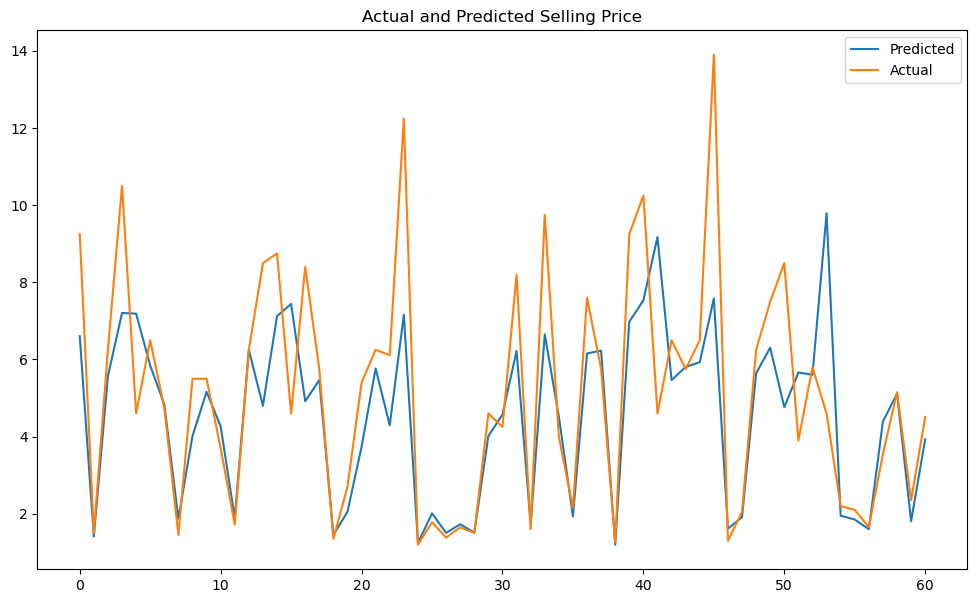

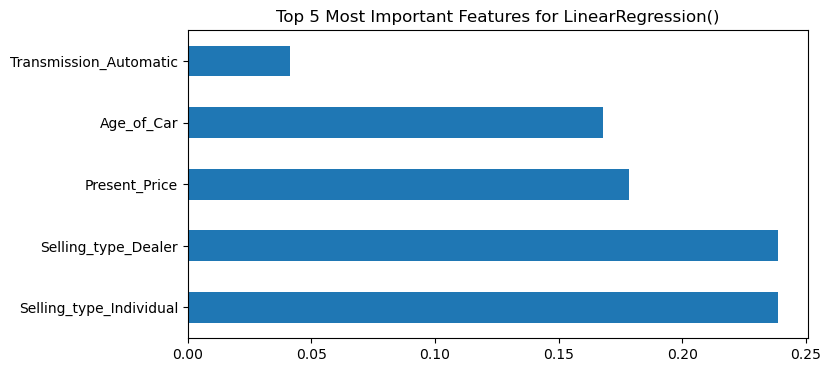

In [49]:
y_pred_lr2 = bestR.predict(X_test)

lreg_score_2 = evaluate_model(bestR, y_test , y_pred_lr2)

In [50]:
Score['Linear Regression(Tuned)'] = lreg_score_2
Score

,Linear regression,Linear Regression(Tuned)
MSE,3.877121,3.877121
RMSE,1.969041,1.969041
MAE,1.267639,1.267639
Train R2,0.625705,0.625705
Test R2,0.571480,0.571480
Adjusted R2,0.475282,0.475282


In this method, I used **GridSearchCV** to find the best hyperparameters for my model.

My goal was to prevent the model from overfitting or underfitting. However, despite the hyperparameter optimization, no significant improvement in performance was observed.

For both the untuned and tuned models, the R², MSE, and MAE scores remained very close.

***

Bu yöntemde, modelimin en iyi hiperparametrelerini bulmak için **GridSearchCV** kullandım.

Hedefim, modelin aşırıya kaçmasını veya eksik öğrenmesini önlemekti. Ancak, yapılan hiperparametre optimizasyonuna rağmen modelin performansında belirgin bir iyileşme gözlemlenmedi.

Hem ayarlanmamış hem de ayarlanmış modelde R², MSE ve MAE değerleri birbirine oldukça yakın kaldı.

### Ridge Regression

In [51]:
ridge = Ridge()

ridge.fit(X_train,y_train)

y_pred_ridge1 = ridge.predict(X_test)

MSE : 3.8788274575216546
RMSE : 1.969473903742229
MAE : 1.2686401674244396
Train R2 : 0.625397987277742
Test R2 : 0.571291781954379
Adjusted R2 :  0.4750511615767906


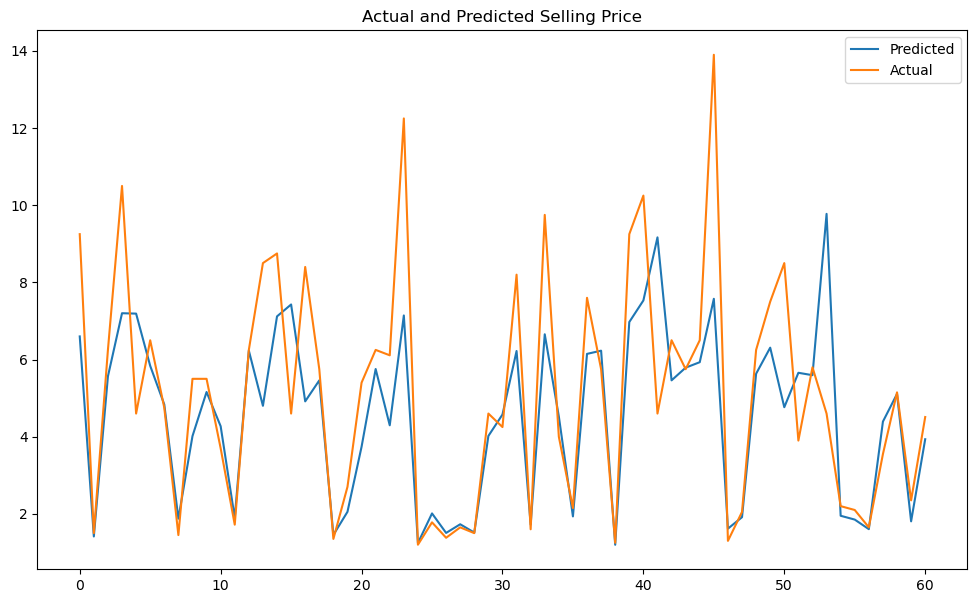

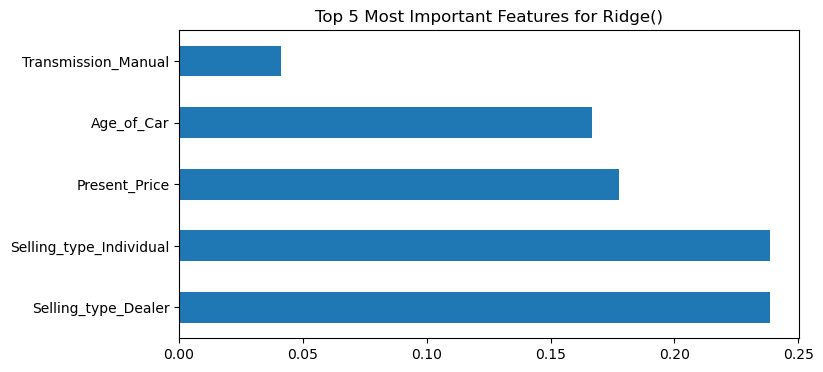

In [52]:
ridge1 = evaluate_model(ridge, y_test, y_pred_ridge1)

Score['Ridge Regression'] = ridge1

In [53]:
Score

,Linear regression,Linear Regression(Tuned),Ridge Regression
MSE,3.877121,3.877121,3.878827
RMSE,1.969041,1.969041,1.969474
MAE,1.267639,1.267639,1.268640
Train R2,0.625705,0.625705,0.625398
Test R2,0.571480,0.571480,0.571292
Adjusted R2,0.475282,0.475282,0.475051


#### 2. Cross Validation & Hyperparameter Tuning / Çapraz Doğrulama ve Hiperparametre Ayarlamaları

In [54]:
ridge = Ridge()

parameters = {'alpha': [1e-20, 1e-15, 1e-12, 1e-10, 1e-8, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 2, 5, 10, 20, 30, 35, 40, 45, 50, 55, 60, 65, 70, 80, 100]}

ridge_regressor = GridSearchCV(ridge,parameters, scoring = 'neg_mean_squared_error', cv = 5)

ridge_regressor.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1e-20, 1e-15, 1e-12, 1e-10, 1e-08, 1e-05,
                                   0.0001, 0.001, 0.01, 0.1, 1, 2, 5, 10, 20,
                                   30, 35, 40, 45, 50, 55, 60, 65, 70, 80,
                                   100]},
             scoring='neg_mean_squared_error')

In [55]:
best_alpha = ridge_regressor.best_params_['alpha']
best_score = ridge_regressor.best_score_

print(f"The Ridge model performed best with alpha = {best_alpha}.")
print(f"The corresponding negative mean squared error is {best_score:.5f}.")

The Ridge model performed best with alpha = 30.
The corresponding negative mean squared error is -0.10538.


In [56]:
ridge = Ridge(alpha = best_alpha)

ridge.fit(X_train,y_train)

y_pred_ridge2 = ridge.predict(X_test)

MSE : 3.954512552222211
RMSE : 1.9885956231024473
MAE : 1.3108076650073457
Train R2 : 0.6145844272285894
Test R2 : 0.5629266709931349
Adjusted R2 :  0.4648081685630223


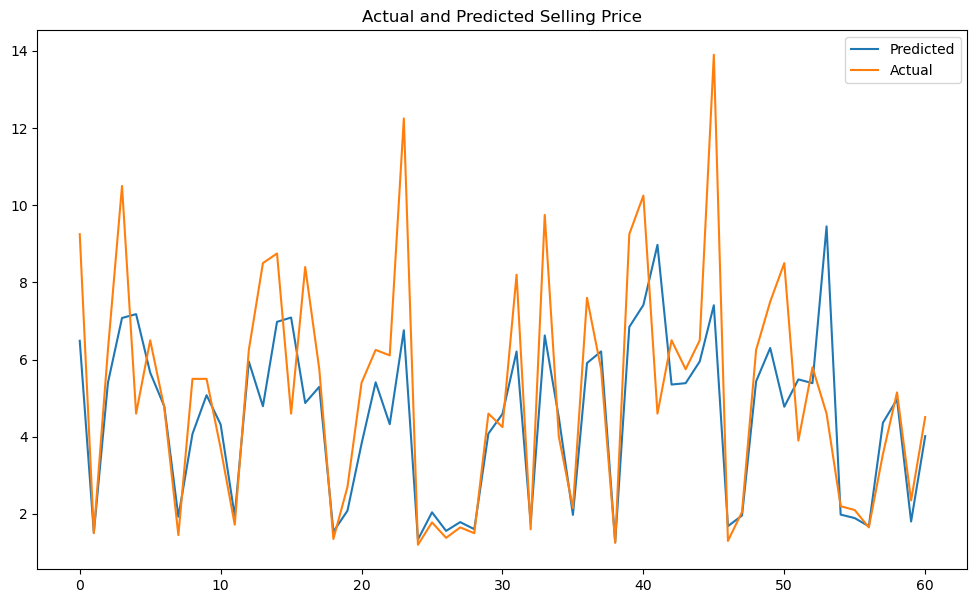

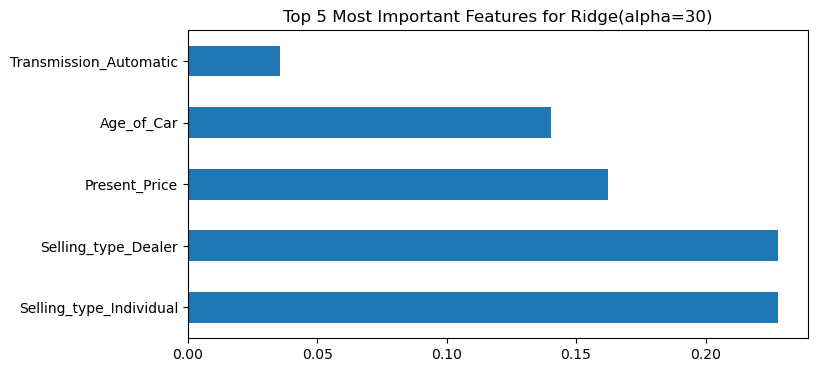

In [57]:
ridge_result = evaluate_model(ridge, y_test, y_pred_ridge2)

ridge_tuned = 'Ridge with Alpha = ' + str(best_alpha)

Score[ridge_tuned] = ridge_result

In [58]:
Score

,Linear regression,Linear Regression(Tuned),Ridge Regression,Ridge with Alpha = 30
MSE,3.877121,3.877121,3.878827,3.954513
RMSE,1.969041,1.969041,1.969474,1.988596
MAE,1.267639,1.267639,1.268640,1.310808
Train R2,0.625705,0.625705,0.625398,0.614584
Test R2,0.571480,0.571480,0.571292,0.562927
Adjusted R2,0.475282,0.475282,0.475051,0.464808


### Lasso Regression

In [59]:
lasso  = Lasso()

lasso.fit(X_train,y_train)

y_pred_lasso_1 = lasso.predict(X_test)

#### 1. ML Model and Performance Evaluation / ML Modeli ve Performans Değerlendirmesi

MSE : 11.146459529426565
RMSE : 3.338631385676856
MAE : 2.662008268361656
Train R2 : -0.0997880770538675
Test R2 : -0.23196477665220172
Adjusted R2 :  -0.5085282979414716


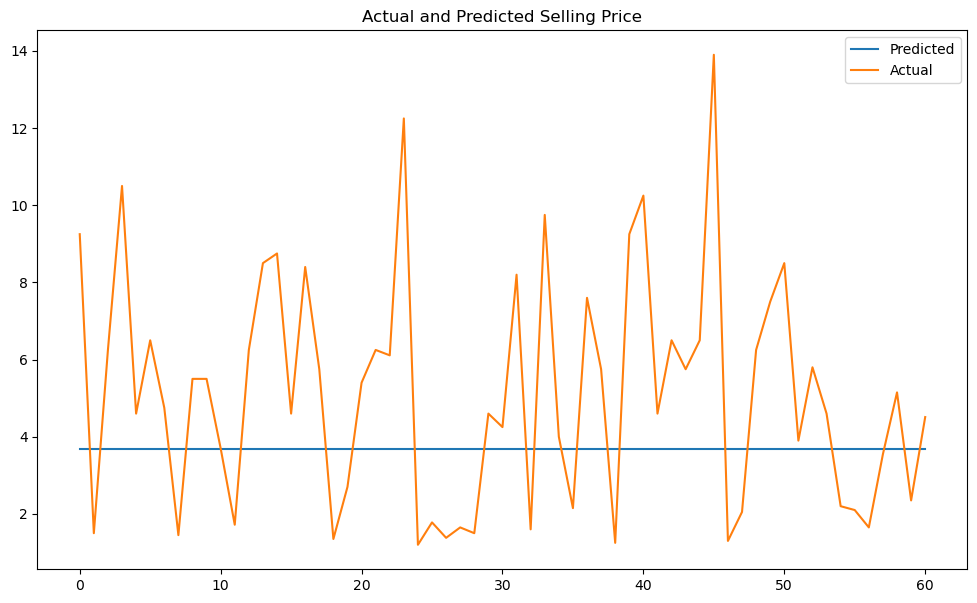

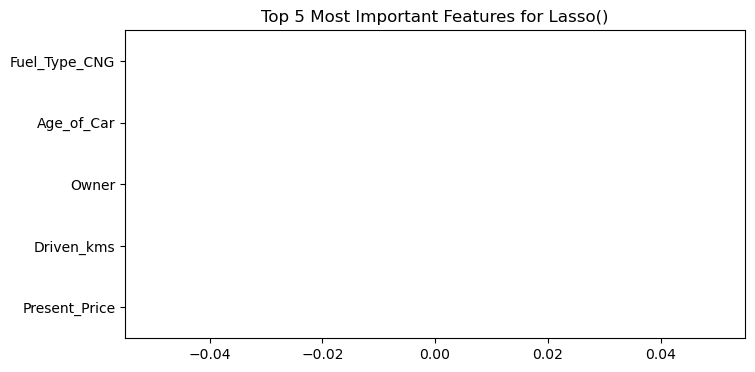

In [60]:
result_lasso = evaluate_model(lasso, y_test, y_pred_lasso_1)

Score['Lasso Regression'] = result_lasso

In [61]:
Score

,Linear regression,Linear Regression(Tuned),Ridge Regression,Ridge with Alpha = 30,Lasso Regression
MSE,3.877121,3.877121,3.878827,3.954513,11.146460
RMSE,1.969041,1.969041,1.969474,1.988596,3.338631
MAE,1.267639,1.267639,1.268640,1.310808,2.662008
Train R2,0.625705,0.625705,0.625398,0.614584,-0.099788
Test R2,0.571480,0.571480,0.571292,0.562927,-0.231965
Adjusted R2,0.475282,0.475282,0.475051,0.464808,-0.508528


#### 2. Cross Validation & Hyperparameter Tuning / Çapraz Doğrulama ve Hiperparametre Ayarlamaları

In [62]:
parameters = {'alpha' : [1e-20, 1e-15, 1e-10, 1e-8, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1,2,5,10,20,30,40,45,50,55,60,65,100]}

lasso_Regressor = GridSearchCV(lasso, parameters, scoring = 'neg_mean_squared_error',cv = 5)

lasso_Regressor.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1e-20, 1e-15, 1e-10, 1e-08, 1e-05, 0.0001,
                                   0.001, 0.01, 0.1, 1, 2, 5, 10, 20, 30, 40,
                                   45, 50, 55, 60, 65, 100]},
             scoring='neg_mean_squared_error')

In [63]:
print("The best alpha value identified is:", lasso_Regressor.best_params_)
print("\nWith", lasso_Regressor.best_params_, "the achieved negative mean squared error is:", lasso_Regressor.best_score_)


The best alpha value identified is: {'alpha': 0.01}

With {'alpha': 0.01} the achieved negative mean squared error is: -0.10717962354587438


In [64]:
lasso = Lasso(alpha = lasso_Regressor.best_params_['alpha'])

lasso.fit(X_train, y_train)

y_pred_lasso2 = lasso.predict(X_test)

MSE : 3.998941294820198
RMSE : 1.9997353061893461
MAE : 1.2886385026309632
Train R2 : 0.6162235290912478
Test R2 : 0.5580161749017823
Adjusted R2 :  0.4587953162062641


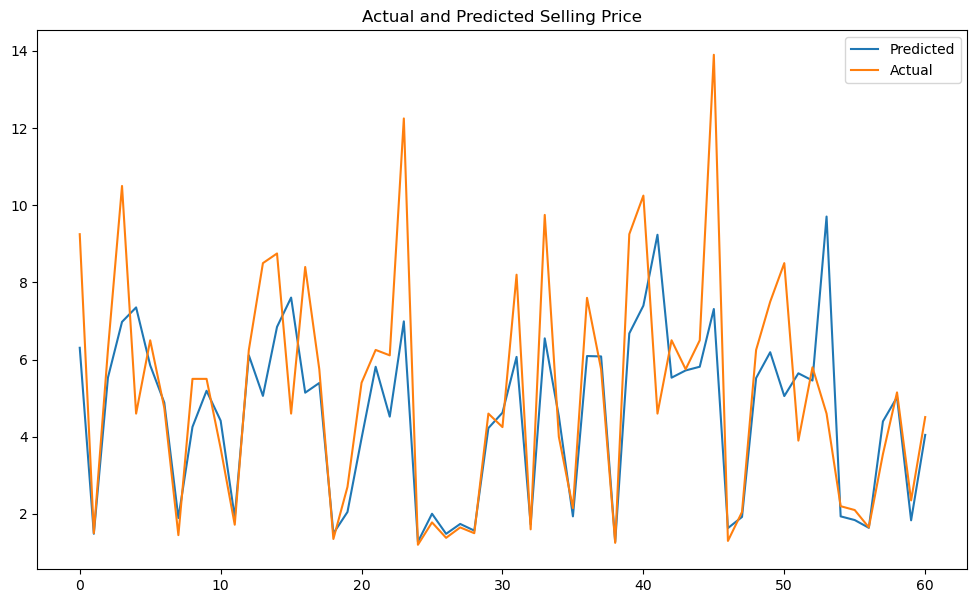

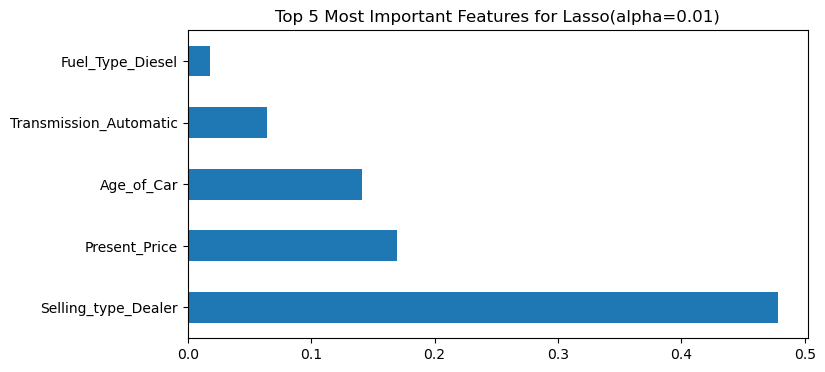

In [65]:
lasso_2 = evaluate_model(lasso, y_test, y_pred_lasso2)

lasso_new = 'Lasso with Alpha = ' + str(lasso_Regressor.best_params_['alpha'])

Score[lasso_new] = lasso_2

In [66]:
Score

,Linear regression,Linear Regression(Tuned),Ridge Regression,Ridge with Alpha = 30,Lasso Regression,Lasso with Alpha = 0.01
MSE,3.877121,3.877121,3.878827,3.954513,11.146460,3.998941
RMSE,1.969041,1.969041,1.969474,1.988596,3.338631,1.999735
MAE,1.267639,1.267639,1.268640,1.310808,2.662008,1.288639
Train R2,0.625705,0.625705,0.625398,0.614584,-0.099788,0.616224
Test R2,0.571480,0.571480,0.571292,0.562927,-0.231965,0.558016
Adjusted R2,0.475282,0.475282,0.475051,0.464808,-0.508528,0.458795


### Decision Tree

In [67]:
dTree = DecisionTreeRegressor(random_state = 1)

dTree.fit(X_train,y_train)

y_pred_dT1 = dTree.predict(X_test)

#### 1. ML Model and Performance Evaluation / ML Modeli ve Performans Değerlendirmesi

MSE : 0.6978639344262301
RMSE : 0.8353825078526783
MAE : 0.5713114754098363
Train R2 : 1.0
Test R2 : 0.9228684423211406
Adjusted R2 :  0.9055531946789477


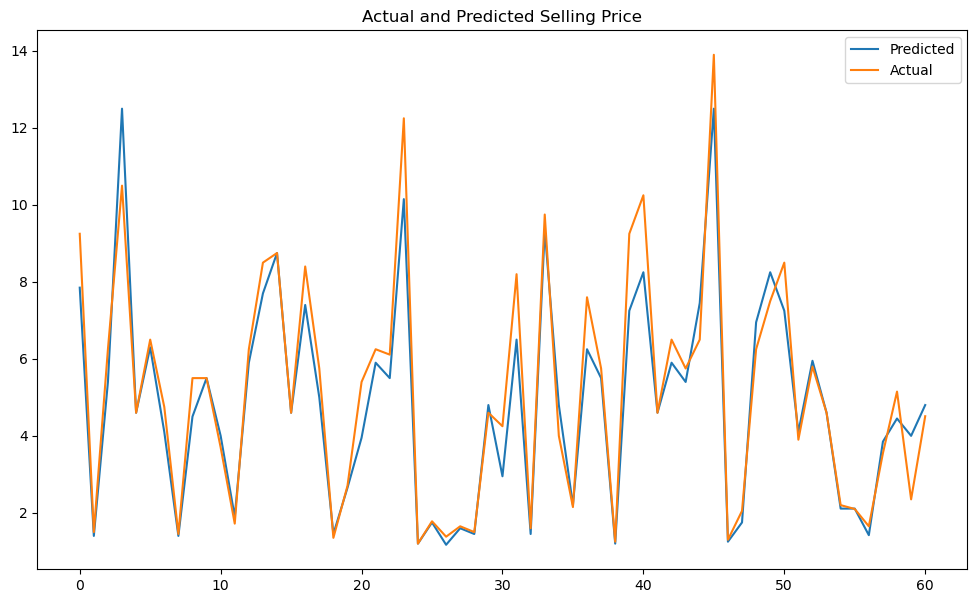

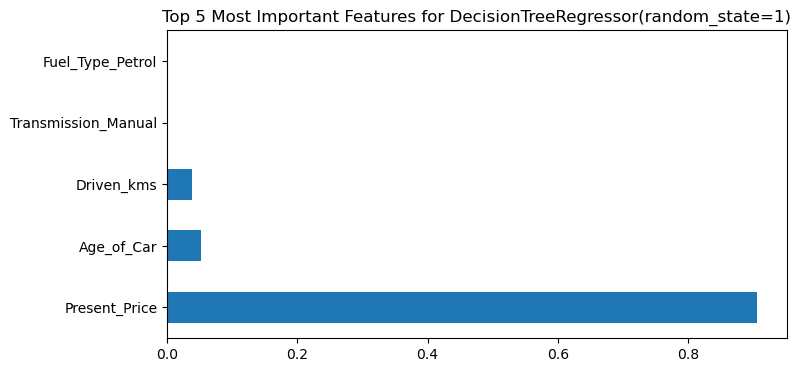

In [68]:
result_dT = evaluate_model(dTree, y_test, y_pred_dT1)
Score['Decision Tree'] = result_dT

In [69]:
Score

,Linear regression,Linear Regression(Tuned),Ridge Regression,Ridge with Alpha = 30,Lasso Regression,Lasso with Alpha = 0.01,Decision Tree
MSE,3.877121,3.877121,3.878827,3.954513,11.146460,3.998941,0.697864
RMSE,1.969041,1.969041,1.969474,1.988596,3.338631,1.999735,0.835383
MAE,1.267639,1.267639,1.268640,1.310808,2.662008,1.288639,0.571311
Train R2,0.625705,0.625705,0.625398,0.614584,-0.099788,0.616224,1.000000
Test R2,0.571480,0.571480,0.571292,0.562927,-0.231965,0.558016,0.922868
Adjusted R2,0.475282,0.475282,0.475051,0.464808,-0.508528,0.458795,0.905553


#### 2. Cross Validation & Hyperparameter Tuning / Çapraz Doğrulama ve Hiperparametre Ayarlamaları

In [70]:
dT_model = DecisionTreeRegressor(random_state=1)

Grid = {'max_depth': [8,10,12,14,16],
        'min_samples_split' : np.arange(30,50),
        'min_samples_leaf': np.arange(20,30,2)}

dT_gridSearch = GridSearchCV(dT_model, Grid, cv=6, scoring = 'neg_root_mean_squared_error')

dT_gridSearch.fit(X_train,y_train)
dT_bestParams = dT_gridSearch.best_params_

In [71]:
dT_bestParams

{'max_depth': 8, 'min_samples_leaf': 20, 'min_samples_split': 46}

In [72]:
dT_model = DecisionTreeRegressor(max_depth = dT_bestParams['max_depth'],
                                 min_samples_leaf = dT_bestParams['min_samples_leaf'],
                                 min_samples_split = dT_bestParams['min_samples_split'],
                                 random_state = 1)

In [73]:
dT_model.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, min_samples_split=46,
                      random_state=1)

In [74]:
y_pred_dT2 = dT_model.predict(X_test)

MSE : 2.994609794205266
RMSE : 1.7304940896187038
MAE : 1.1382540203877634
Train R2 : 0.7811668649789929
Test R2 : 0.6690201245930166
Adjusted R2 :  0.5947185199098163


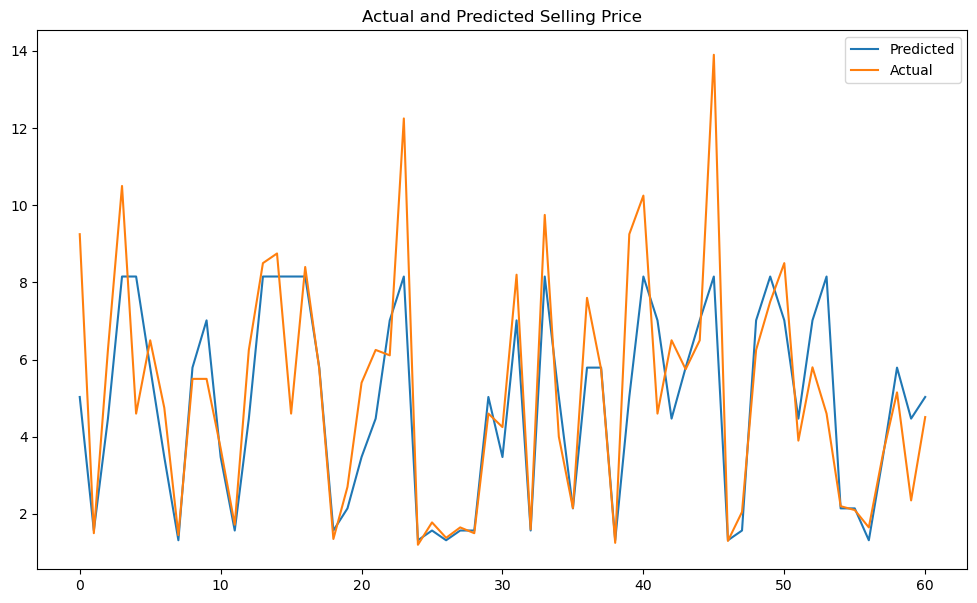

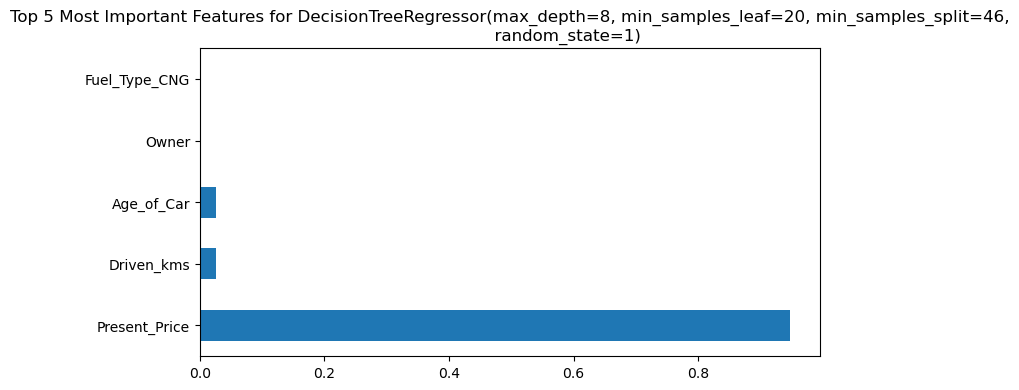

In [75]:
result_dT2 = evaluate_model(dT_model, y_test, y_pred_dT2)
Score['Decision Tree (Tuned)'] = result_dT2

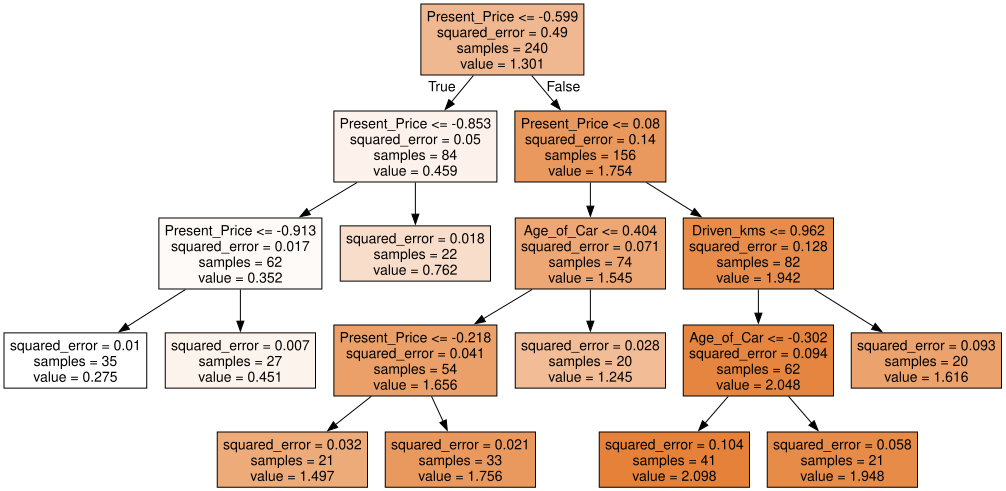

In [76]:
graph_dt = Source(tree.export_graphviz(dT_model, out_file = None, feature_names = Features, filled = True))

display(SVG(graph_dt.pipe(format = 'svg')))

In [77]:
Score

,Linear regression,Linear Regression(Tuned),Ridge Regression,Ridge with Alpha = 30,Lasso Regression,Lasso with Alpha = 0.01,Decision Tree,Decision Tree (Tuned)
MSE,3.877121,3.877121,3.878827,3.954513,11.146460,3.998941,0.697864,2.994610
RMSE,1.969041,1.969041,1.969474,1.988596,3.338631,1.999735,0.835383,1.730494
MAE,1.267639,1.267639,1.268640,1.310808,2.662008,1.288639,0.571311,1.138254
Train R2,0.625705,0.625705,0.625398,0.614584,-0.099788,0.616224,1.000000,0.781167
Test R2,0.571480,0.571480,0.571292,0.562927,-0.231965,0.558016,0.922868,0.669020
Adjusted R2,0.475282,0.475282,0.475051,0.464808,-0.508528,0.458795,0.905553,0.594719


After tuning the Decision Tree Regressor, the model no longer shows signs of overfitting. The tuned model achieves an R² of approximately 0.78 on the training set and 0.67 on the test set, indicating a more balanced performance and better generalization to unseen data.
***
Decision Tree Regresyon Modeli' tuning işleminden sonra artık overfitting göstermemektedir. Ayarlanmış model, eğitim verisi üzerinde yaklaşık 0.78 R² ve test verisi üzerinde 0.67 R² değerine ulaşmakta, bu da modelin daha dengeli bir performans sergilediğini ve yeni verilere daha iyi genelleme yapabildiğini göstermektedir.

### Random Forest

In [78]:
rfr = RandomForestRegressor(random_state = 0)

rfr.fit(X_train,y_train)

y_pred_rfr1 = rfr.predict(X_test)

#### 1. ML Model and Performance Evaluation / ML Modeli ve Performans Değerlendirmesi

MSE : 0.47163908252199227
RMSE : 0.6867598434110663
MAE : 0.46921160318440164
Train R2 : 0.9852291194182592
Test R2 : 0.9478719915121293
Adjusted R2 :  0.9361697855250563


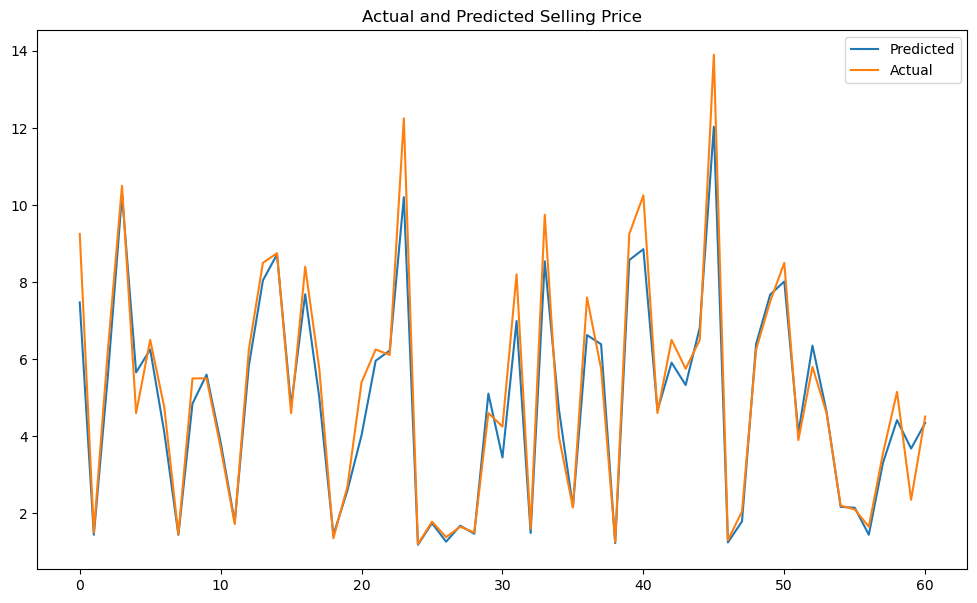

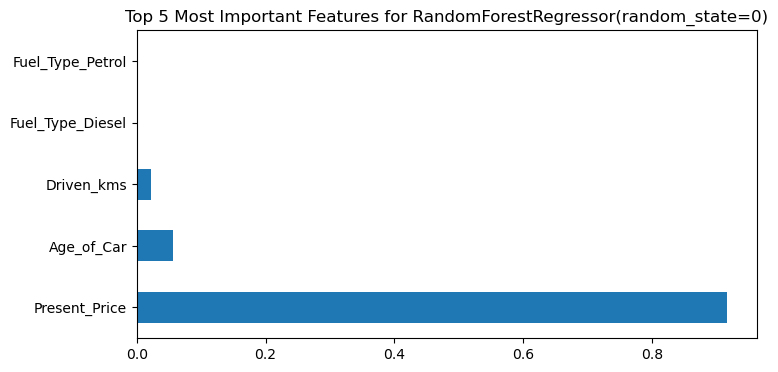

In [79]:
result_rf = evaluate_model(rfr, y_test, y_pred_rfr1)
Score['Random Forest'] = result_rf

In [80]:
Score

,Linear regression,Linear Regression(Tuned),Ridge Regression,Ridge with Alpha = 30,Lasso Regression,Lasso with Alpha = 0.01,Decision Tree,Decision Tree (Tuned),Random Forest
MSE,3.877121,3.877121,3.878827,3.954513,11.146460,3.998941,0.697864,2.994610,0.471639
RMSE,1.969041,1.969041,1.969474,1.988596,3.338631,1.999735,0.835383,1.730494,0.686760
MAE,1.267639,1.267639,1.268640,1.310808,2.662008,1.288639,0.571311,1.138254,0.469212
Train R2,0.625705,0.625705,0.625398,0.614584,-0.099788,0.616224,1.000000,0.781167,0.985229
Test R2,0.571480,0.571480,0.571292,0.562927,-0.231965,0.558016,0.922868,0.669020,0.947872
Adjusted R2,0.475282,0.475282,0.475051,0.464808,-0.508528,0.458795,0.905553,0.594719,0.936170


Here, I observed that using a **Random Forest Regressor**, the model achieves approximately 98% R² on the training set and 94% R² on the test set, indicating that it is a strong model for prediction.
***
Burada, **Random Forest Regressor** modeli kullanıldığında, modelin eğitim verisi üzerinde yaklaşık %98 R², test verisi üzerinde ise %94 R² elde ettiğini gözlemledim. Bu, modelin tahmin için güçlü bir seçenek olduğunu göstermektedir.

#### 2. Cross Validation & Hyperparameter Tuning / Çapraz Doğrulama ve Hiperparametre Ayarlamaları

In [81]:
rfr_model = RandomForestRegressor(random_state = 0)
rfr_params = {'n_estimators' : [300], 'min_samples_leaf': np.arange(18,25)}

In [82]:
rfr_gridsearch = GridSearchCV(rfr_model, rfr_params, cv = 6, scoring = 'neg_root_mean_squared_error')
rfr_gridsearch.fit(X_train,y_train)
rfr_best_params = rfr_gridsearch.best_params_

In [83]:
rfr_best_params

{'min_samples_leaf': 18, 'n_estimators': 300}

In [84]:
rfr_model = RandomForestRegressor(n_estimators = rfr_best_params['n_estimators'],
                                  min_samples_leaf = rfr_best_params['min_samples_leaf'],
                                  random_state = 0)

In [85]:
rfr_model.fit(X_train,y_train)

RandomForestRegressor(min_samples_leaf=18, n_estimators=300, random_state=0)

MSE : 2.3153611827600993
RMSE : 1.5216310928605854
MAE : 1.0203171964660387
Train R2 : 0.7818274099512729
Test R2 : 0.7440942197961786
Adjusted R2 :  0.6866459834238922


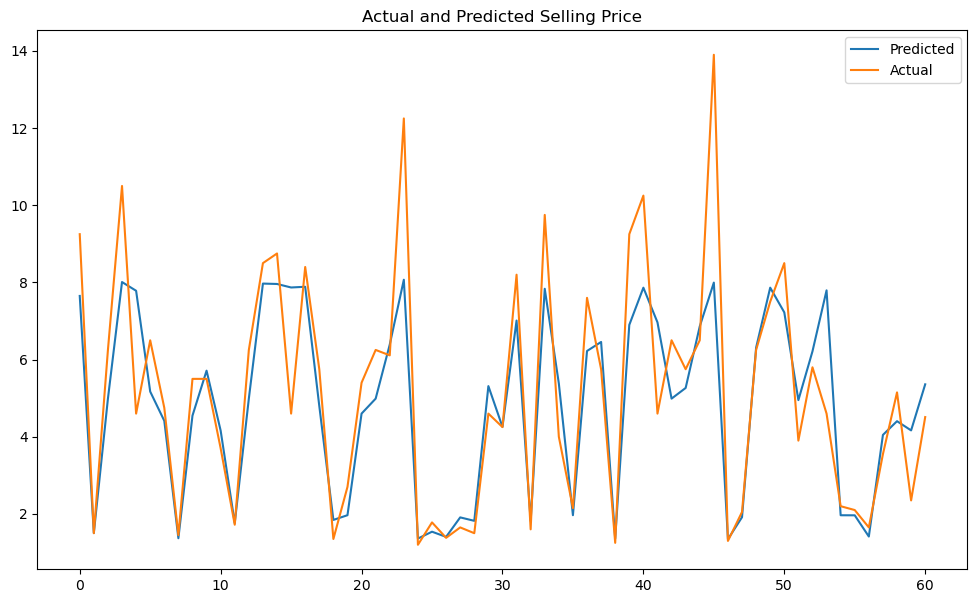

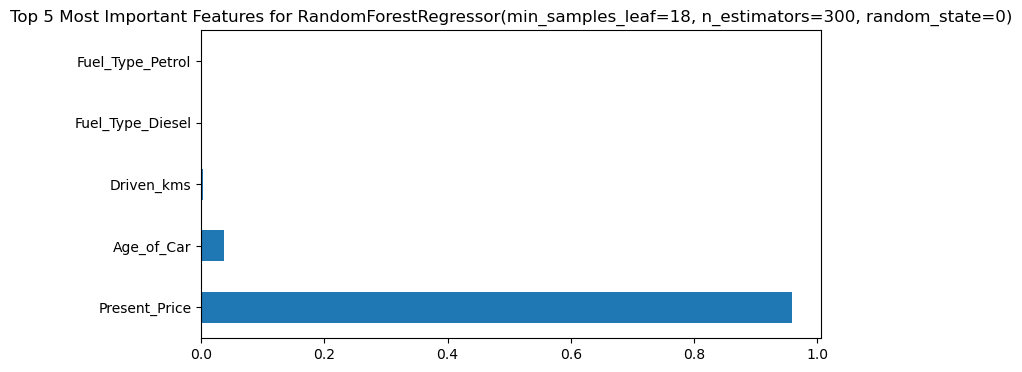

In [86]:
y_pred_rfr2 = rfr_model.predict(X_test)

result_rf2 = evaluate_model(rfr_model, y_test, y_pred_rfr2)
Score['Random Forest (Tuned)'] = result_rf2

In [87]:
Score

,Linear regression,Linear Regression(Tuned),Ridge Regression,Ridge with Alpha = 30,Lasso Regression,Lasso with Alpha = 0.01,Decision Tree,Decision Tree (Tuned),Random Forest,Random Forest (Tuned)
MSE,3.877121,3.877121,3.878827,3.954513,11.146460,3.998941,0.697864,2.994610,0.471639,2.315361
RMSE,1.969041,1.969041,1.969474,1.988596,3.338631,1.999735,0.835383,1.730494,0.686760,1.521631
MAE,1.267639,1.267639,1.268640,1.310808,2.662008,1.288639,0.571311,1.138254,0.469212,1.020317
Train R2,0.625705,0.625705,0.625398,0.614584,-0.099788,0.616224,1.000000,0.781167,0.985229,0.781827
Test R2,0.571480,0.571480,0.571292,0.562927,-0.231965,0.558016,0.922868,0.669020,0.947872,0.744094
Adjusted R2,0.475282,0.475282,0.475051,0.464808,-0.508528,0.458795,0.905553,0.594719,0.936170,0.686646


After tuning the **Random Forest Regressor**, the model no longer shows the severe overfitting observed initially.

Previously, the model achieved Train R² ≈ 0.9852 and Test R² ≈ 0.948, indicating strong overfitting.

After tuning, the performance is more balanced, with Train R² ≈ 0.7818, Test R² ≈ 0.7440, and Adjusted R² ≈ 0.6866, demonstrating improved generalization to unseen data.
***
**Random Forest Regressor** modeli tuning işleminden sonra, başlangıçta gözlenen aşırı overfitting artık görülmemektedir.

Önceden model, eğitim verisi üzerinde Train R² ≈ 0.9852 ve test verisi üzerinde Test R² ≈ 0.948 elde ederek ciddi overfitting sergiliyordu.

Tuning sonrası performans daha dengeli hâle geldi: Train R² ≈ 0.7818, Test R² ≈ 0.7440 ve Adjusted R² ≈ 0.6866, bu da modelin yeni verilere daha iyi genelleme yaptığını göstermektedir.

### Gradient Boosting Regressor

In [88]:
gbr = GradientBoostingRegressor(random_state = 0)

gbr.fit(X_train,y_train)

y_pred_gbr1 = gbr.predict(X_test)

#### 1. ML Model and Performance Evaluation / ML Modeli ve Performans Değerlendirmesi

MSE : 0.7280201368668022
RMSE : 0.8532409606124183
MAE : 0.5385815030460815
Train R2 : 0.9853952631013068
Test R2 : 0.9195354217233177
Adjusted R2 :  0.9014719449673279


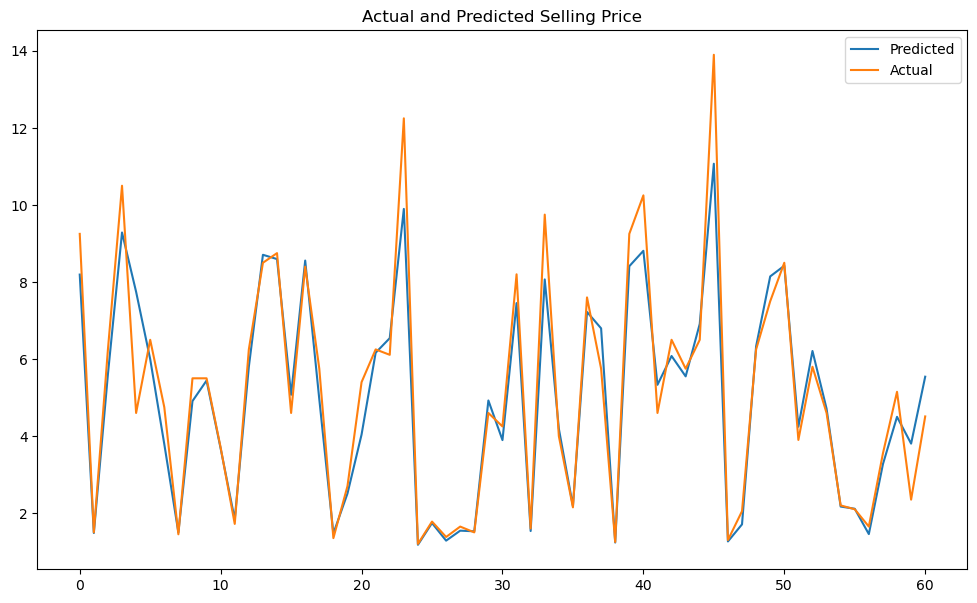

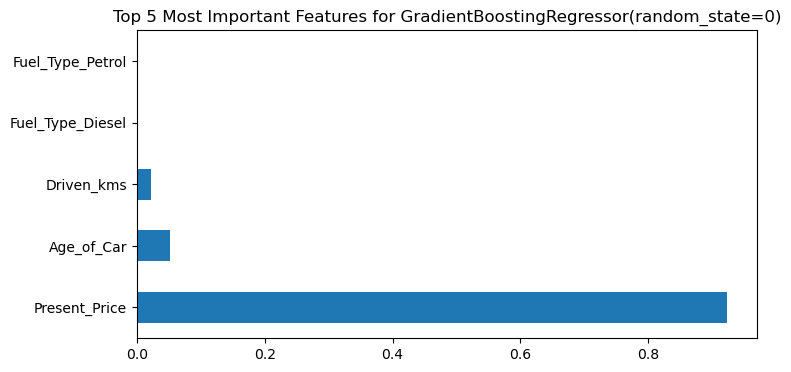

In [89]:
result_gbr = evaluate_model(gbr, y_test, y_pred_gbr1)

Score['Gradient Boosting Regressor'] = result_gbr

In [90]:
Score

,Linear regression,Linear Regression(Tuned),Ridge Regression,Ridge with Alpha = 30,Lasso Regression,Lasso with Alpha = 0.01,Decision Tree,Decision Tree (Tuned),Random Forest,Random Forest (Tuned),Gradient Boosting Regressor
MSE,3.877121,3.877121,3.878827,3.954513,11.146460,3.998941,0.697864,2.994610,0.471639,2.315361,0.728020
RMSE,1.969041,1.969041,1.969474,1.988596,3.338631,1.999735,0.835383,1.730494,0.686760,1.521631,0.853241
MAE,1.267639,1.267639,1.268640,1.310808,2.662008,1.288639,0.571311,1.138254,0.469212,1.020317,0.538582
Train R2,0.625705,0.625705,0.625398,0.614584,-0.099788,0.616224,1.000000,0.781167,0.985229,0.781827,0.985395
Test R2,0.571480,0.571480,0.571292,0.562927,-0.231965,0.558016,0.922868,0.669020,0.947872,0.744094,0.919535
Adjusted R2,0.475282,0.475282,0.475051,0.464808,-0.508528,0.458795,0.905553,0.594719,0.936170,0.686646,0.901472


#### 2. Cross Validation & Hyperparameter Tuning / Çapraz Doğrulama ve Hiperparametre Ayarlamaları

In [91]:
gbr_model = GradientBoostingRegressor(random_state = 0)
gbr_params = {'n_estimators' : [300],
              'min_samples_leaf' : np.arange(20,25),
              'max_depth' : np.arange(14,20)}

In [92]:
random_search_gbr = RandomizedSearchCV(gbr_model, param_distributions = gbr_params, cv = 6,
                                        n_iter = 20, scoring = 'neg_root_mean_squared_error', n_jobs = -1)
random_search_gbr.fit(X_train,y_train)

gbr_best_params = random_search_gbr.best_params_

In [93]:
gbr_best_params

{'n_estimators': 300, 'min_samples_leaf': 23, 'max_depth': 19}

In [94]:
gbr_model = GradientBoostingRegressor(n_estimators = gbr_best_params['n_estimators'],
                                      min_samples_leaf = gbr_best_params['min_samples_leaf'],
                                      max_depth = gbr_best_params['max_depth'],
                                      random_state = 0)

gbr_model.fit(X_train,y_train)

GradientBoostingRegressor(max_depth=19, min_samples_leaf=23, n_estimators=300,
                          random_state=0)

MSE : 0.9790392437656963
RMSE : 0.989464119493828
MAE : 0.6303547818915142
Train R2 : 0.9674864349463462
Test R2 : 0.891791482300246
Adjusted R2 :  0.8674997742451991


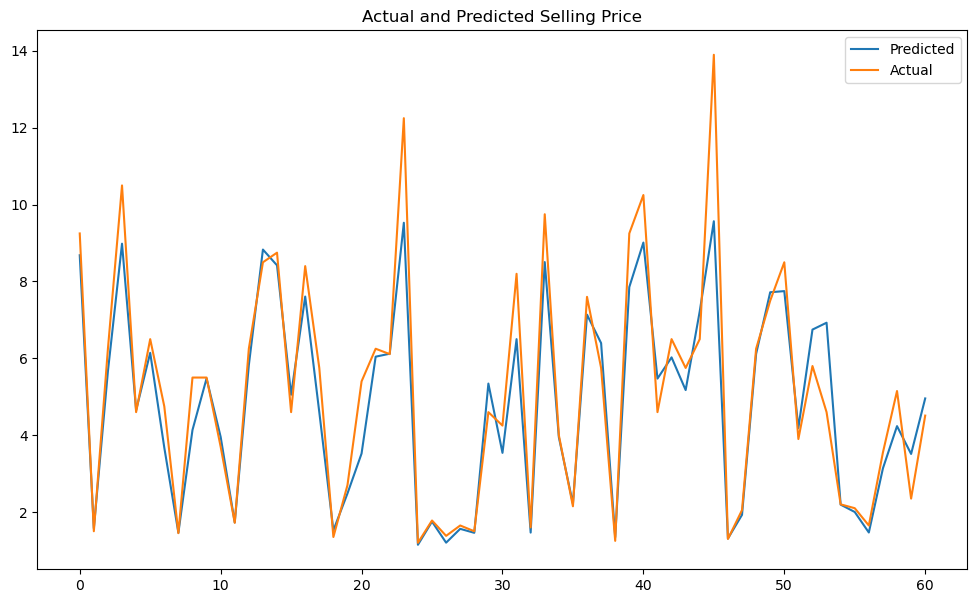

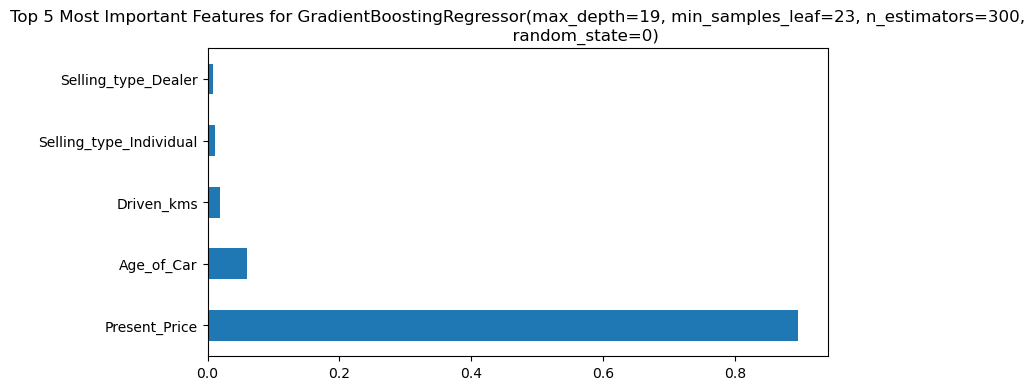

In [95]:
y_pred_gbr2 = gbr_model.predict(X_test)

result_gbr2 = evaluate_model(gbr_model, y_test, y_pred_gbr2)

Score['Gradient Boosting Regressor (Tuned)'] = result_gbr2

In [96]:
Score

,Linear regression,Linear Regression(Tuned),Ridge Regression,Ridge with Alpha = 30,Lasso Regression,Lasso with Alpha = 0.01,Decision Tree,Decision Tree (Tuned),Random Forest,Random Forest (Tuned),Gradient Boosting Regressor,Gradient Boosting Regressor (Tuned)
MSE,3.877121,3.877121,3.878827,3.954513,11.146460,3.998941,0.697864,2.994610,0.471639,2.315361,0.728020,0.979039
RMSE,1.969041,1.969041,1.969474,1.988596,3.338631,1.999735,0.835383,1.730494,0.686760,1.521631,0.853241,0.989464
MAE,1.267639,1.267639,1.268640,1.310808,2.662008,1.288639,0.571311,1.138254,0.469212,1.020317,0.538582,0.630355
Train R2,0.625705,0.625705,0.625398,0.614584,-0.099788,0.616224,1.000000,0.781167,0.985229,0.781827,0.985395,0.967486
Test R2,0.571480,0.571480,0.571292,0.562927,-0.231965,0.558016,0.922868,0.669020,0.947872,0.744094,0.919535,0.891791
Adjusted R2,0.475282,0.475282,0.475051,0.464808,-0.508528,0.458795,0.905553,0.594719,0.936170,0.686646,0.901472,0.867500


In this project, I built a machine learning model to predict car prices. For hyperparameter optimization, I used RandomizedSearchCV, which samples hyperparameters randomly instead of testing all possible combinations, making the search process faster and more efficient. 

I also applied cross-validation to avoid overfitting and ensure more reliable results.

After tuning, I observed a clear improvement in model performance. The updated evaluation metric scores are presented in the performance chart.
***
Bu projede, araç fiyatlarını tahmin etmek için bir makine öğrenimi modeli geliştirdim. Hiperparametre optimizasyonu için RandomizedSearchCV yöntemini kullandım. Bu yöntem, tüm kombinasyonları denemek yerine hiperparametre uzayından rastgele örnekler seçerek daha hızlı ve verimli bir arama yapmamı sağladı. 

Ayrıca, cross-validation kullanarak modelin aşırı öğrenmesini önledim.

Bu yaklaşım sonucunda modelin performansında belirgin bir iyileşme gözlemledim. Güncel değerlendirme metriği (örneğin R² veya RMSE) sonuçlarını grafikte paylaştım.

### Model Performance Comparison (R² Scores) / Modellerin Performans Karşılaştırması (R² Skorları)

In [97]:
Score

,Linear regression,Linear Regression(Tuned),Ridge Regression,Ridge with Alpha = 30,Lasso Regression,Lasso with Alpha = 0.01,Decision Tree,Decision Tree (Tuned),Random Forest,Random Forest (Tuned),Gradient Boosting Regressor,Gradient Boosting Regressor (Tuned)
MSE,3.877121,3.877121,3.878827,3.954513,11.146460,3.998941,0.697864,2.994610,0.471639,2.315361,0.728020,0.979039
RMSE,1.969041,1.969041,1.969474,1.988596,3.338631,1.999735,0.835383,1.730494,0.686760,1.521631,0.853241,0.989464
MAE,1.267639,1.267639,1.268640,1.310808,2.662008,1.288639,0.571311,1.138254,0.469212,1.020317,0.538582,0.630355
Train R2,0.625705,0.625705,0.625398,0.614584,-0.099788,0.616224,1.000000,0.781167,0.985229,0.781827,0.985395,0.967486
Test R2,0.571480,0.571480,0.571292,0.562927,-0.231965,0.558016,0.922868,0.669020,0.947872,0.744094,0.919535,0.891791
Adjusted R2,0.475282,0.475282,0.475051,0.464808,-0.508528,0.458795,0.905553,0.594719,0.936170,0.686646,0.901472,0.867500


In [98]:
Score.columns

Index(['Linear regression', 'Linear Regression(Tuned)', 'Ridge Regression',
       'Ridge with Alpha = 30', 'Lasso Regression', 'Lasso with Alpha = 0.01',
       'Decision Tree', 'Decision Tree (Tuned)', 'Random Forest',
       'Random Forest (Tuned)', 'Gradient Boosting Regressor',
       'Gradient Boosting Regressor (Tuned)'],
      dtype='object')

In [99]:
# Plotting R^2 Scores

reg_models = list(Score.columns)
train_R2 = Score.iloc[3,:]
test_R2 = Score.iloc[4,:]

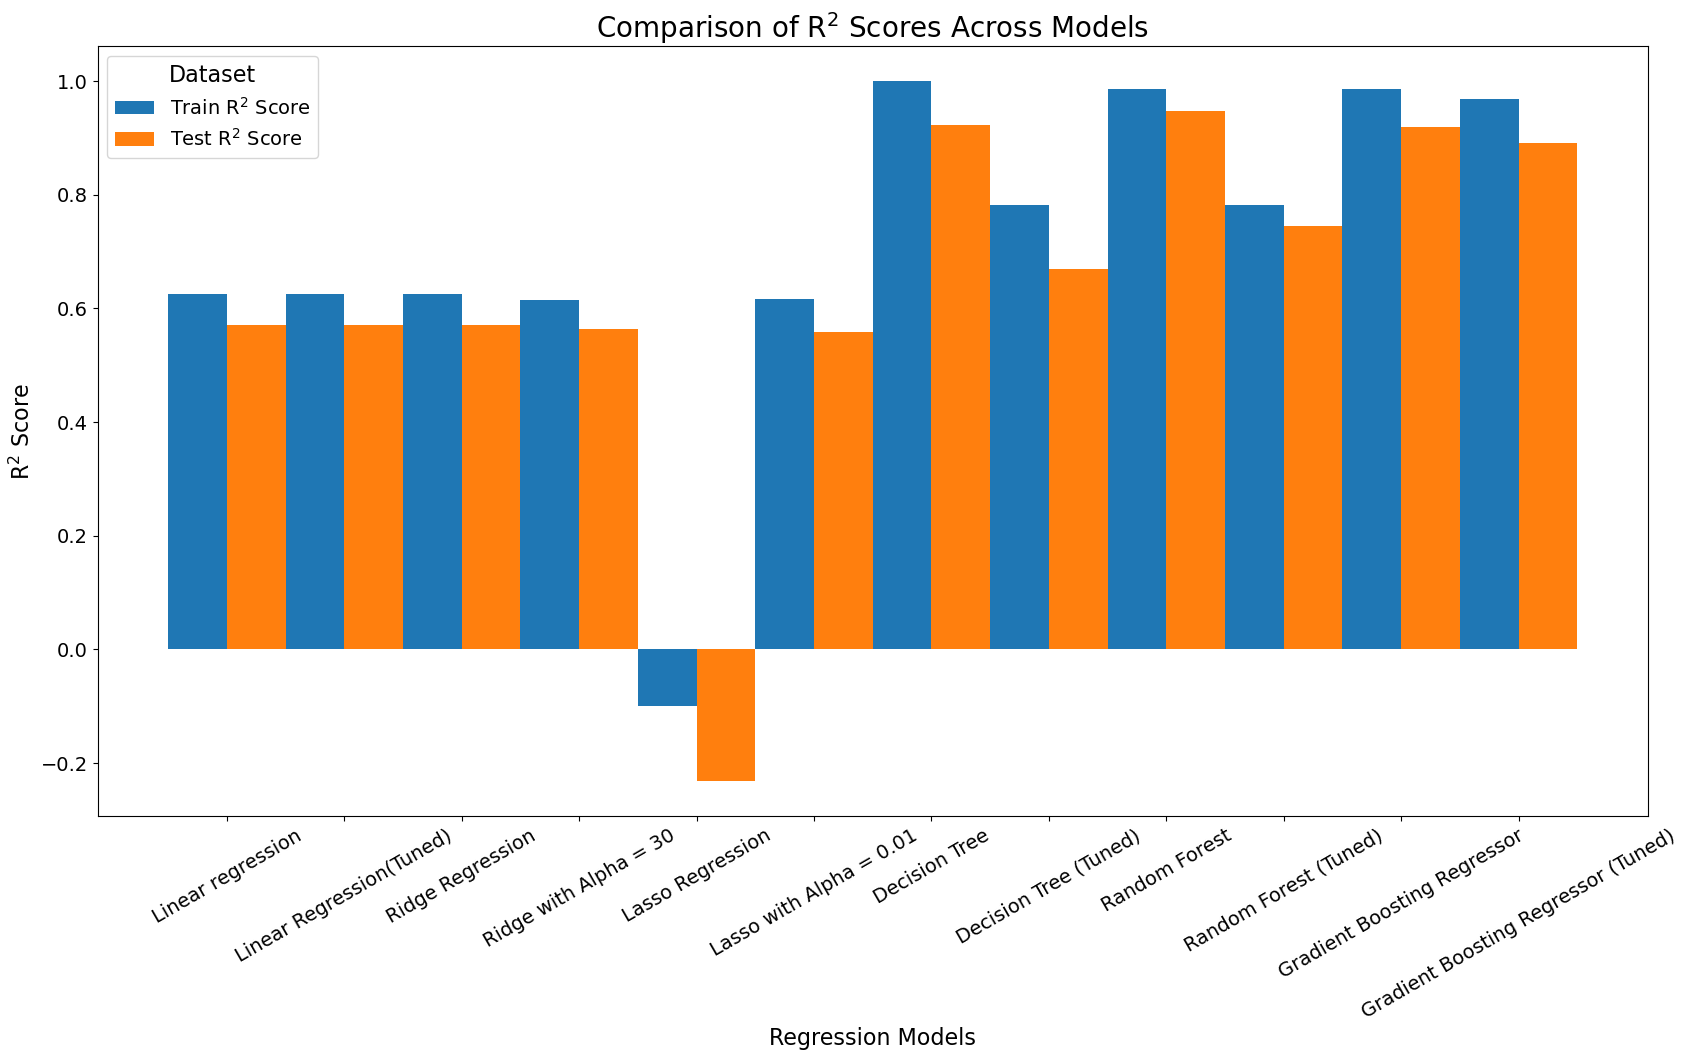

In [100]:
x_axis = np.arange(len(reg_models))

plt.figure(figsize = (20,10))
plt.bar(x_axis - 0.25, train_R2, 0.5, label = 'Train R$^2$ Score')
plt.bar(x_axis + 0.25, test_R2, 0.5, label = 'Test R$^2$ Score')

plt.xticks(x_axis, reg_models, rotation=30, fontsize=14)            # X tick yazıları
plt.yticks(fontsize=14)                                             # Y tick yazıları
plt.xlabel("Regression Models", fontsize=16)                        # X ekseni etiketi
plt.ylabel("R$^2$ Score", fontsize=16)                              # Y ekseni etiketi
plt.title("Comparison of R$^2$ Scores Across Models", fontsize=20)  # Başlık
plt.legend(title="Dataset", fontsize=14, title_fontsize=16)   
plt.show()

### 1. Evaluation metric considered and why:
I used R² score because it reliably shows how well the model explains the variance, making it a good indicator of accuracy and business relevance.

### 2. Final prediction model and why:
I tried several models including Linear Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost. I chose Random Forest as it gave the best balance, with 98% training R² and 94% testing R². Other models were overfitted.

***

### 1. Değerlendirme metriği ve nedeni:
İş açısından uygulanabilirlik ve doğruluk için R² skorunu kullandım, çünkü modelin verideki değişkenliği ne kadar açıkladığını gösteriyor.

### 2. Son tahmin modeli ve nedeni:
Lineer Regresyon, Karar Ağacı, Random Forest, Gradient Boosting ve XGBoost’u denedim. En iyi dengeyi sağlayan Random Forest’ı seçtim (%98 eğitim R², %93 test R²). Diğer modeller aşırı öğrenme gösterdi.

## Conclusion

This project explores the automotive industry with the goal of predicting car prices using machine learning. By analyzing key features like fuel type, seller type, transmission, year, and ownership, we gain insights into market trends and consumer preferences.

**Key Insights:**

* The most popular car models in the dataset are **City, Corolla Altis, Verna, Fortuner, and Brio**.
* Cars from **2015, 2016, and 2014** are the most frequently sold.
* **Petrol** is the dominant fuel type, and **manual** transmission cars are more common than automatic ones.
* Cars sold by **dealers** usually have higher prices than those sold by individuals.
* **First-owner** cars tend to be more expensive, and cars with fewer kilometers sell for higher prices.
* **Diesel** vehicles generally have higher selling prices than petrol or CNG cars.

Several machine learning models were evaluated, and the **Random Forest Regressor** was selected for price prediction due to its strong performance. The model achieved **98% R² on training data** and **94% R² on testing data**, showing reliable generalization and suitability for practical applications.

This project highlights important factors influencing car prices and demonstrates the potential of machine learning in the automotive market, while also providing hands-on experience in data analysis and predictive modeling.

***
## Sonuç

Bu proje, otomotiv sektöründe araç fiyatlarını tahmin etmek amacıyla **makine öğrenmesi** yöntemlerini kullanmaktadır. Yakıt türü, satıcı tipi, vites türü, üretim yılı ve sahiplik gibi temel özellikler analiz edilerek piyasa trendleri ve tüketici tercihleri hakkında önemli bilgiler elde edilmiştir.

**Öne Çıkan Bulgular:**

* Veri setindeki en popüler modeller: **City, Corolla Altis, Verna, Fortuner ve Brio**.
* En çok satış yapılan yıllar: **2015, 2016 ve 2014**.
* **Benzinli** araçlar daha yaygın ve **manuel** vitesli araçlar otomatiklere göre daha fazla.
* **Bayiler** aracılığıyla satılan araçlar genellikle bireysel satıcılardan daha yüksek fiyatla alıcı buluyor.
* **İlk sahipli** araçlar daha yüksek fiyatlı, az kilometreli araçlar ise daha değerli.
* **Dizel** araçlar genellikle benzinli veya CNG araçlardan daha yüksek fiyatlara sahip.

Farklı makine öğrenmesi modelleri değerlendirildikten sonra, fiyat tahmini için **Random Forest Regressor** seçilmiştir. Model, **%98 eğitim R²** ve **%94 test R²** başarısı ile güvenilir bir performans göstermiştir.

Bu proje, araç fiyatlarını etkileyen önemli faktörleri ortaya koyarken, makine öğrenmesinin otomotiv sektöründe pratik uygulamalarda nasıl kullanılabileceğini de göstermektedir. Ayrıca veri analizi ve tahmin modelleme konularında değerli deneyim kazandırmaktadır.